#### This document is for analysis on FACT-E emotional well being (EWB).

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import re

# Preliminary

In [3]:
# Read the CSV file - linked file 
file_path = "Merged_TSQIC_REDCap_ACCESS.xlsx" 
df = pd.read_excel(file_path)
df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,NaT,NaN,1949-08-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-05-27,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27
4,1,2009-02-25,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,1788,NaT,baseline_arm_1,NaT,NaN,1947-03-23,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11965,1788,NaT,baseline_arm_1,2025-06-09,NaN,NaT,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,2.0,2.0,0.0,NaN,NaN,NaN,NaT
11966,1788,NaT,baseline_arm_1,NaT,NaN,NaT,3,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11967,1789,NaT,baseline_arm_1,NaT,NaN,1945-08-19,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


In [4]:
def preprocess_patient_data(df):
    """
    Preprocess patient data with expectation_treatment filtering:
    Filter out patients with expectation_treatment != 1 (if information is available)
    """
    
    # Make a copy to avoid modifying original dataframe
    df_processed = df.copy()
    
    # Step 1: expectation_treatment filtering (keep only patients with expectation_treatment == 1)
    print("Step 1: Filtering patients by expectation_treatment...")
    
    # Group by patient id again for expectation_treatment check
    patient_groups = df_processed.groupby('id')
    patients_to_keep = []
    
    for patient_id, group in patient_groups:
        keep_patient = True
        
        # Check if expectation_treatment column exists and has data for this patient
        if 'expectation_treatment' in group.columns:
            expectation_available = group['expectation_treatment'].notna().any()
            
            if expectation_available:
                # Check if any row has expectation_treatment == 1
                has_expectation_treatment = (group['expectation_treatment'] == 1).any()
                
                if not has_expectation_treatment:
                    keep_patient = False
                    print(f"Patient {patient_id}: Filtered out (no expectation_treatment == 1)")
        
        # If patient should be kept, add all their rows
        if keep_patient:
            patients_to_keep.extend(group.index.tolist())
    
    # Filter dataframe to keep only selected patients
    df_processed = df_processed.loc[patients_to_keep]
    print(f"After expectation_treatment filtering: {len(df_processed)} rows remaining")
    
    return df_processed

# Optional: Function to get summary statistics
def get_filtering_summary(df_original, df_filtered):
    """
    Print summary of filtering results
    """
    original_patients = df_original['id'].nunique()
    filtered_patients = df_filtered['id'].nunique()
    original_rows = len(df_original)
    filtered_rows = len(df_filtered)
    
    print(f"\n=== Filtering Summary ===")
    print(f"Original patients: {original_patients}")
    print(f"Filtered patients: {filtered_patients}")
    print(f"Patients removed: {original_patients - filtered_patients}")
    print(f"Original rows: {original_rows}")
    print(f"Filtered rows: {filtered_rows}")
    print(f"Rows removed: {original_rows - filtered_rows}")

# Example usage:
df_filtered = preprocess_patient_data(df)
get_filtering_summary(df, df_filtered)

Step 1: Filtering patients by expectation_treatment...
Patient 8: Filtered out (no expectation_treatment == 1)
Patient 59: Filtered out (no expectation_treatment == 1)
Patient 1179: Filtered out (no expectation_treatment == 1)
After expectation_treatment filtering: 11940 rows remaining

=== Filtering Summary ===
Original patients: 1688
Filtered patients: 1685
Patients removed: 3
Original rows: 11969
Filtered rows: 11940
Rows removed: 29


In [5]:
df = df_filtered.copy()
df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5,a_e6,a_e7,a_c6,a_c2,a_act11,readmission_30d,postop_comp,los,DischargeDate
0,1,NaT,baseline_arm_1,NaT,NaN,1949-08-04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,2012-04-27
1,1,2011-08-26,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-08-26
2,1,2010-02-20,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,2010-03-08
3,1,2009-05-27,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2009-05-27
4,1,2009-02-25,NaN,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,2009-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,1788,NaT,baseline_arm_1,NaT,NaN,1947-03-23,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11965,1788,NaT,baseline_arm_1,2025-06-09,NaN,NaT,NaN,NaN,NaN,NaN,...,0.0,2.0,0.0,2.0,2.0,0.0,NaN,NaN,NaN,NaT
11966,1788,NaT,baseline_arm_1,NaT,NaN,NaT,3,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
11967,1789,NaT,baseline_arm_1,NaT,NaN,1945-08-19,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT


# Preliminary 2

In [6]:
df['id'].nunique()

1685

In [7]:
df['redcap_event_name'].value_counts()

redcap_event_name
baseline_arm_1           3862
surgery_arm_1            3831
preoperative_arm_1       1755
1_month_postop_arm_1      903
1_year_postop_arm_1       350
6_months_postop_arm_1     327
3_months_postop_arm_1     256
Name: count, dtype: int64

# Analysis

In [8]:
# Step 1: Find eligible IDs (unchanged)
def find_eligible_ids(df):
    id_events = df.groupby('id')['redcap_event_name'].apply(set)
    eligible_ids = []
    follow_up_events = {"1_month_postop_arm_1", "3_months_postop_arm_1", 
                        "6_months_postop_arm_1", "1_year_postop_arm_1"}
    
    for id_val, events in id_events.items():
        has_baseline = "baseline_arm_1" in events
        has_preop = "preoperative_arm_1" in events
        has_any_followup = bool(events.intersection(follow_up_events))
        
        if (has_baseline and has_any_followup) or (has_preop and has_any_followup):
            eligible_ids.append(id_val)
    return eligible_ids

# Step 2: Filter dataset (unchanged)
def filter_eligible_data(df, eligible_ids):
    return df[df['id'].isin(eligible_ids)].copy()

# Step 3: Calculate all subscale scores (unchanged)
def calculate_subscale_score(df, cols, reverse_items=None, subscale_name=""):
    """Calculate subscale scores according to FACT scoring guidelines, only if >=50% items are answered"""
    # Convert to numeric and handle reverse scoring
    for col in cols:
        df[f"{col}_score"] = pd.to_numeric(df[col], errors='coerce')
        if reverse_items and col in reverse_items:
            df[f"{col}_score"] = 4 - df[f"{col}_score"]
    
    # Calculate the number of items and the 50% threshold
    total_items = len(cols)
    min_items_required = total_items / 2  # 50% threshold
    
    # Count non-NaN items for each row
    score_cols = [f"{col}_score" for col in cols]
    num_answered_items = df[score_cols].notna().sum(axis=1)
    
    # Calculate subscale score only if >=50% items are answered
    df[f"{subscale_name}_subscale_score"] = np.where(
        num_answered_items >= min_items_required,
        (df[score_cols].sum(axis=1, skipna=True) * total_items) / 
        df[score_cols].notna().sum(axis=1),
        np.nan
    )
    return df

def calculate_all_scores(df):
    pwb_cols = [f"gp{i}" for i in range(1, 8)]
    swb_cols = [f"gs{i}" for i in range(1, 8)]
    ewb_cols = [f"ge{i}" for i in range(1, 7)]
    fwb_cols = [f"gf{i}" for i in range(1, 8)]
    ecs_cols = [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]

    pwb_reverse = pwb_cols
    ewb_reverse = [f"ge{i}" for i in range(1, 7) if i != 2]
    ecs_reverse = ["a_e1", "a_e2", "a_e3", "a_e4", "a_e5", "a_e7", "a_act11", 
                    "a_c2", "a_hn2", "a_hn3"]

    df = calculate_subscale_score(df, pwb_cols, pwb_reverse, "pwb")
    df = calculate_subscale_score(df, swb_cols, None, "swb")
    df = calculate_subscale_score(df, ewb_cols, ewb_reverse, "ewb")
    df = calculate_subscale_score(df, fwb_cols, None, "fwb")
    df = calculate_subscale_score(df, ecs_cols, ecs_reverse, "ecs")

    # Calculate composite scores with both conditions
    # 1. FACT-G Total (PWB + SWB + EWB + FWB)
    fact_g_items = pwb_cols + swb_cols + ewb_cols + fwb_cols  # 27 items
    fact_g_item_cols = [f"{col}_score" for col in fact_g_items]
    fact_g_num_answered = df[fact_g_item_cols].notna().sum(axis=1)
    fact_g_min_items = 22  # 80% of 27 items = 21.6, rounded up to 22
    
    df['fact_g_total'] = np.where(
        # Condition 1: All subscales must be non-NaN (already ensures 50% of items per subscale)
        (df["pwb_subscale_score"].notna()) & 
        (df["swb_subscale_score"].notna()) & 
        (df["ewb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-G items must be answered
        (fact_g_num_answered >= fact_g_min_items),
        df["pwb_subscale_score"] + df["swb_subscale_score"] + 
        df["ewb_subscale_score"] + df["fwb_subscale_score"],
        np.nan
    )
    
    # 2. FACT-E Total (FACT-G + ECS)
    fact_e_items = fact_g_items + ecs_cols  # 27 + 17 = 44 items
    fact_e_item_cols = [f"{col}_score" for col in fact_e_items]
    fact_e_num_answered = df[fact_e_item_cols].notna().sum(axis=1)
    fact_e_min_items = 36  # 80% of 44 items = 35.2, rounded up to 36
    
    df['fact_e_total'] = np.where(
        # Condition 1: FACT-G and ECS must be non-NaN
        (df['fact_g_total'].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of FACT-E items must be answered
        (fact_e_num_answered >= fact_e_min_items),
        df['fact_g_total'] + df["ecs_subscale_score"],
        np.nan
    )
    
    # 3. TOI (PWB + FWB + ECS)
    toi_items = pwb_cols + fwb_cols + ecs_cols  # 7 + 7 + 17 = 31 items
    toi_item_cols = [f"{col}_score" for col in toi_items]
    toi_num_answered = df[toi_item_cols].notna().sum(axis=1)
    toi_min_items = 25  # 80% of 31 items = 24.8, rounded up to 25
    
    df['toi'] = np.where(
        # Condition 1: PWB, FWB, and ECS must be non-NaN
        (df["pwb_subscale_score"].notna()) & 
        (df["fwb_subscale_score"].notna()) & 
        (df["ecs_subscale_score"].notna()) &
        # Condition 2: At least 80% of TOI items must be answered
        (toi_num_answered >= toi_min_items),
        df["pwb_subscale_score"] + df["fwb_subscale_score"] + df["ecs_subscale_score"],
        np.nan
    )

    return df

# Step 4: Analyze trajectory for all scores (fixed)
def analyze_trajectories(df):
    results = []
    unique_ids = df['id'].unique()
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    
    for id_val in unique_ids:
        id_data = df[df['id'] == id_val]
        events = id_data['redcap_event_name'].unique()
        print(f"\nID {id_val} has events: {events}")
        
        event_scores = id_data.groupby('redcap_event_name')[score_types].mean().reset_index()
        
        baseline_score = event_scores[event_scores['redcap_event_name'] == 'baseline_arm_1']
        preop_score = event_scores[event_scores['redcap_event_name'] == 'preoperative_arm_1']
        one_month_score = event_scores[event_scores['redcap_event_name'] == '1_month_postop_arm_1']
        three_month_score = event_scores[event_scores['redcap_event_name'] == '3_months_postop_arm_1']
        six_month_score = event_scores[event_scores['redcap_event_name'] == '6_months_postop_arm_1']
        one_year_score = event_scores[event_scores['redcap_event_name'] == '1_year_postop_arm_1']
        
        # Get values for each timepoint (or NaN if missing)
        one_month_values = one_month_score[score_types].iloc[0].to_dict() if not one_month_score.empty else {k: np.nan for k in score_types}
        three_month_values = three_month_score[score_types].iloc[0].to_dict() if not three_month_score.empty else {k: np.nan for k in score_types}
        six_month_values = six_month_score[score_types].iloc[0].to_dict() if not six_month_score.empty else {k: np.nan for k in score_types}
        one_year_values = one_year_score[score_types].iloc[0].to_dict() if not one_year_score.empty else {k: np.nan for k in score_types}
        
        # Print scores for all timepoints
        if not baseline_score.empty:
            baseline_values = baseline_score[score_types].iloc[0].to_dict()
            print(f"Baseline score: [{', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}]")
        else:
            print("Baseline score: [nan]")
            
        if not preop_score.empty:
            preop_values = preop_score[score_types].iloc[0].to_dict()
            print(f"Preop score: [{', '.join([f'{k}: {v:.1f}' for k, v in preop_values.items() if pd.notna(v)])}]")
        else:
            print("Preop score: [nan]")
            
        print(f"1-month score: [{', '.join([f'{k}: {v:.1f}' for k, v in one_month_values.items() if pd.notna(v)])}]")
        print(f"3-month score: [{', '.join([f'{k}: {v:.1f}' for k, v in three_month_values.items() if pd.notna(v)])}]")
        print(f"6-month score: [{', '.join([f'{k}: {v:.1f}' for k, v in six_month_values.items() if pd.notna(v)])}]")
        print(f"1-year score: [{', '.join([f'{k}: {v:.1f}' for k, v in one_year_values.items() if pd.notna(v)])}]")
        
        # Determine which baseline to use (same logic as before)
        baseline_type = None
        baseline_values = None
        
        # Check if baseline_score exists and has non-NaN values
        if not baseline_score.empty:
            baseline_values_temp = baseline_score[score_types].iloc[0].to_dict()
            # Check if at least one score is non-NaN
            if any(pd.notna(val) for val in baseline_values_temp.values()):
                baseline_type = 'baseline_arm_1'
                baseline_values = baseline_values_temp
                print(f"Using baseline score: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # If baseline is not valid, fall back to preop
        if baseline_values is None and not preop_score.empty:
            preop_values_temp = preop_score[score_types].iloc[0].to_dict()
            if any(pd.notna(val) for val in preop_values_temp.values()):
                baseline_type = 'preoperative_arm_1'
                baseline_values = preop_values_temp
                print(f"Using preop score as baseline: {', '.join([f'{k}: {v:.1f}' for k, v in baseline_values.items() if pd.notna(v)])}")
        
        # Skip if no valid baseline
        if baseline_values is None:
            continue
        
        # Store all timepoint data
        result = {'id': id_val, 'baseline_type': baseline_type}
        for score_type in score_types:
            result.update({
                f'{score_type}_baseline': baseline_values[score_type],
                f'{score_type}_one_month': one_month_values[score_type],
                f'{score_type}_three_month': three_month_values[score_type],
                f'{score_type}_six_month': six_month_values[score_type],
                f'{score_type}_one_year': one_year_values[score_type]
            })
        
        results.append(result)
    
    return pd.DataFrame(results)

# Main function (unchanged)
def analyze_patient_outcomes(df):
    required_cols = ['id', 'redcap_event_name'] + \
                    [f"gp{i}" for i in range(1, 8)] + \
                    [f"gs{i}" for i in range(1, 8)] + \
                    [f"ge{i}" for i in range(1, 7)] + \
                    [f"gf{i}" for i in range(1, 8)] + \
                    [f"a_hn{i}" for i in range(1, 6)] + ["a_hn7", "a_hn10"] + \
                    [f"a_e{i}" for i in range(1, 8)] + ["a_c6", "a_c2", "a_act11"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns: {missing_cols}")
    
    eligible_ids = find_eligible_ids(df)
    print(f"Found {len(eligible_ids)} eligible IDs")
    
    filtered_df = filter_eligible_data(df, eligible_ids)
    print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    filtered_df = calculate_all_scores(filtered_df)
    
    score_cols = [col for col in filtered_df.columns if col.endswith('_score') or col.endswith('_total')]
    print(f"Created score columns: {score_cols}")
    
    score_types = ['pwb_subscale_score', 'swb_subscale_score', 'ewb_subscale_score',
                    'fwb_subscale_score', 'ecs_subscale_score', 'fact_g_total',
                    'fact_e_total', 'toi']
    for score_type in score_types:
        non_nan_count = filtered_df[score_type].notna().sum()
        print(f"Non-NaN {score_type}: {non_nan_count} out of {len(filtered_df)}")
    
    results_df = analyze_trajectories(filtered_df)
    
    if not results_df.empty:
        print(f"\nTrajectory analysis complete for {len(results_df)} patients:")
        for score_type in score_types:
            # Count patients with valid baseline scores for this score type
            valid_baselines = results_df[f'{score_type}_baseline'].notna().sum()
            print(f"Patients with valid {score_type} baseline: {valid_baselines} out of {len(results_df)}")
            
    return filtered_df, results_df

# Example usage
filtered_df, results_df = analyze_patient_outcomes(df)

results_df.to_csv("results.csv", index=False)

Found 633 eligible IDs
Filtered dataframe shape: (6835, 84)
Created score columns: ['cci_total', 'gp1_score', 'gp2_score', 'gp3_score', 'gp4_score', 'gp5_score', 'gp6_score', 'gp7_score', 'pwb_subscale_score', 'gs1_score', 'gs2_score', 'gs3_score', 'gs4_score', 'gs5_score', 'gs6_score', 'gs7_score', 'swb_subscale_score', 'ge1_score', 'ge2_score', 'ge3_score', 'ge4_score', 'ge5_score', 'ge6_score', 'ewb_subscale_score', 'gf1_score', 'gf2_score', 'gf3_score', 'gf4_score', 'gf5_score', 'gf6_score', 'gf7_score', 'fwb_subscale_score', 'a_hn1_score', 'a_hn2_score', 'a_hn3_score', 'a_hn4_score', 'a_hn5_score', 'a_hn7_score', 'a_hn10_score', 'a_e1_score', 'a_e2_score', 'a_e3_score', 'a_e4_score', 'a_e5_score', 'a_e6_score', 'a_e7_score', 'a_c6_score', 'a_c2_score', 'a_act11_score', 'ecs_subscale_score', 'fact_g_total', 'fact_e_total']
Non-NaN pwb_subscale_score: 1471 out of 6835
Non-NaN swb_subscale_score: 1455 out of 6835
Non-NaN ewb_subscale_score: 1468 out of 6835
Non-NaN fwb_subscale_score

In [9]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_month,pwb_subscale_score_three_month,pwb_subscale_score_six_month,pwb_subscale_score_one_year,swb_subscale_score_baseline,swb_subscale_score_one_month,swb_subscale_score_three_month,...,fact_e_total_baseline,fact_e_total_one_month,fact_e_total_three_month,fact_e_total_six_month,fact_e_total_one_year,toi_baseline,toi_one_month,toi_three_month,toi_six_month,toi_one_year
0,2,baseline_arm_1,24.0,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,...,141.000000,NaN,NaN,NaN,NaN,108.000000,NaN,NaN,NaN,NaN
1,7,baseline_arm_1,22.0,NaN,NaN,NaN,NaN,26.000000,NaN,NaN,...,106.000000,NaN,NaN,NaN,NaN,75.000000,NaN,NaN,NaN,NaN
2,22,baseline_arm_1,14.0,NaN,NaN,NaN,NaN,25.666667,NaN,NaN,...,89.666667,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN
3,24,baseline_arm_1,28.0,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,...,155.000000,NaN,NaN,NaN,NaN,111.000000,NaN,NaN,NaN,NaN
4,25,baseline_arm_1,28.0,NaN,NaN,NaN,NaN,23.000000,NaN,NaN,...,152.000000,NaN,NaN,NaN,NaN,108.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,1739,baseline_arm_1,28.0,19.0,NaN,NaN,NaN,28.000000,24.500000,NaN,...,150.000000,138.500000,NaN,NaN,NaN,109.000000,94.0,NaN,NaN,NaN
442,1742,baseline_arm_1,20.0,24.0,NaN,NaN,NaN,22.166667,23.333333,NaN,...,130.166667,139.333333,NaN,NaN,NaN,88.000000,95.0,NaN,NaN,NaN
443,1743,baseline_arm_1,20.0,NaN,17.0,NaN,NaN,22.166667,NaN,25.666667,...,130.166667,NaN,126.666667,NaN,NaN,88.000000,NaN,81.0,NaN,NaN
444,1752,preoperative_arm_1,27.0,21.0,NaN,NaN,NaN,28.000000,28.000000,NaN,...,172.000000,139.000000,NaN,NaN,NaN,122.000000,87.0,NaN,NaN,NaN


In [10]:
filtered_df

,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5_score,a_e6_score,a_e7_score,a_c6_score,a_c2_score,a_act11_score,ecs_subscale_score,fact_g_total,fact_e_total,toi
16,2,NaT,baseline_arm_1,NaT,NaN,NaT,3,1,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,2,2007-02-05,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,2,NaT,baseline_arm_1,2007-01-12,NaN,NaT,NaN,NaN,NaN,NaN,...,4.0,4.0,4.0,4.0,4.0,3.0,60.000000,81.0,141.000000,108.000000
19,2,NaT,1_month_postop_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,2,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,1770,NaT,baseline_arm_1,NaT,NaN,1982-10-12,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11909,1770,NaT,preoperative_arm_1,2025-02-24,NaN,NaT,NaN,NaN,NaN,NaN,...,4.0,0.0,4.0,1.0,1.0,1.0,38.636364,58.0,96.636364,67.636364
11910,1770,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11911,1770,NaT,1_month_postop_arm_1,2025-04-28,NaN,NaT,NaN,NaN,NaN,NaN,...,3.0,0.0,4.0,1.0,2.0,4.0,42.000000,68.0,110.000000,75.000000


In [11]:
filtered_df['id'].nunique()

633

In [12]:
results_df['id'].nunique()

446

# Data set up

In [13]:
results_df = pd.read_csv("results.csv")

In [14]:
results_df

,id,baseline_type,pwb_subscale_score_baseline,pwb_subscale_score_one_month,pwb_subscale_score_three_month,pwb_subscale_score_six_month,pwb_subscale_score_one_year,swb_subscale_score_baseline,swb_subscale_score_one_month,swb_subscale_score_three_month,...,fact_e_total_baseline,fact_e_total_one_month,fact_e_total_three_month,fact_e_total_six_month,fact_e_total_one_year,toi_baseline,toi_one_month,toi_three_month,toi_six_month,toi_one_year
0,2,baseline_arm_1,24.0,NaN,NaN,NaN,NaN,19.000000,NaN,NaN,...,141.000000,NaN,NaN,NaN,NaN,108.000000,NaN,NaN,NaN,NaN
1,7,baseline_arm_1,22.0,NaN,NaN,NaN,NaN,26.000000,NaN,NaN,...,106.000000,NaN,NaN,NaN,NaN,75.000000,NaN,NaN,NaN,NaN
2,22,baseline_arm_1,14.0,NaN,NaN,NaN,NaN,25.666667,NaN,NaN,...,89.666667,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN
3,24,baseline_arm_1,28.0,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,...,155.000000,NaN,NaN,NaN,NaN,111.000000,NaN,NaN,NaN,NaN
4,25,baseline_arm_1,28.0,NaN,NaN,NaN,NaN,23.000000,NaN,NaN,...,152.000000,NaN,NaN,NaN,NaN,108.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,1739,baseline_arm_1,28.0,19.0,NaN,NaN,NaN,28.000000,24.500000,NaN,...,150.000000,138.500000,NaN,NaN,NaN,109.000000,94.0,NaN,NaN,NaN
442,1742,baseline_arm_1,20.0,24.0,NaN,NaN,NaN,22.166667,23.333333,NaN,...,130.166667,139.333333,NaN,NaN,NaN,88.000000,95.0,NaN,NaN,NaN
443,1743,baseline_arm_1,20.0,NaN,17.0,NaN,NaN,22.166667,NaN,25.666667,...,130.166667,NaN,126.666667,NaN,NaN,88.000000,NaN,81.0,NaN,NaN
444,1752,preoperative_arm_1,27.0,21.0,NaN,NaN,NaN,28.000000,28.000000,NaN,...,172.000000,139.000000,NaN,NaN,NaN,122.000000,87.0,NaN,NaN,NaN


In [15]:
# Select relevant columns for FACT-E trajectory analysis
results_df = results_df[['id', 'baseline_type', 'fact_e_total_baseline', 'fact_e_total_one_month', 
                        'fact_e_total_three_month', 'fact_e_total_six_month', 'fact_e_total_one_year']]

# Rename columns to match timepoints
results_df = results_df.rename(columns={
    "fact_e_total_baseline": "Baseline",
    "fact_e_total_one_month": "1mo",
    "fact_e_total_three_month": "3mo", 
    "fact_e_total_six_month": "6mo",
    "fact_e_total_one_year": "12mo"
})

In [16]:
# Filter to patients who have baseline AND at least one follow-up
follow_up_cols = ["1mo", "3mo", "6mo", "12mo"]
has_baseline = results_df["Baseline"].notna()
has_followup = results_df[follow_up_cols].notna().any(axis=1)
results_df = results_df[has_baseline & has_followup]

print(f"Patients with valid baseline and at least one follow-up: {len(results_df)}")

Patients with valid baseline and at least one follow-up: 312


In [17]:
# Set 'id' column as the index
results_df = results_df.set_index("id")

# Rename the index and columns to match the second image
results_df.index.name = "id"
results_df.columns.name = "Timepoint"

results_df
score_comparison=results_df.copy()

In [18]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [19]:
score_comparison['baseline_type'].value_counts()

baseline_type
baseline_arm_1        265
preoperative_arm_1     47
Name: count, dtype: int64

In [20]:
# Get IDs from score_comparison
valid_ids = score_comparison.index.tolist()

# Filter filtered_df to only include these patients
lcgm_data = filtered_df[filtered_df['id'].isin(valid_ids)].copy()

# lcgm_data = lcgm_data[['id', 'redcap_event_name', 'fact_e_total']].copy()

# # Step 1: remove rows with missing fact_e_total if (id, redcap_event_name) is duplicated
# lcgm_data = lcgm_data[
#     ~(
#         lcgm_data['fact_e_total'].isna() &
#         lcgm_data.duplicated(subset=['id', 'redcap_event_name'], keep=False)
#     )
# ]

# # Step 2: drop exact duplicates across all three columns
# lcgm_data = lcgm_data.drop_duplicates()

# print(f"LCGM dataset shape: {lcgm_data.shape}")
# print(f"Unique patients in LCGM data: {lcgm_data['id'].nunique()}")
# print(f"Timepoints available:\n{lcgm_data['redcap_event_name'].value_counts()}")
lcgm_data


,id,operation_date,redcap_event_name,qol_date,age_diagnosis,dob,overall_primary_tumour,overall_regional_ln,overall_distant_metastasis,neotx___notx,...,a_e5_score,a_e6_score,a_e7_score,a_c6_score,a_c2_score,a_act11_score,ecs_subscale_score,fact_g_total,fact_e_total,toi
198,27,2006-02-07,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
199,27,NaT,1_month_postop_arm_1,2006-03-14,NaN,NaT,NaN,NaN,NaN,NaN,...,4.0,2.0,3.0,2.0,4.0,4.0,55.000000,96.0,151.000000,103.000000
200,27,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201,27,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
202,27,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11908,1770,NaT,baseline_arm_1,NaT,NaN,1982-10-12,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11909,1770,NaT,preoperative_arm_1,2025-02-24,NaN,NaT,NaN,NaN,NaN,NaN,...,4.0,0.0,4.0,1.0,1.0,1.0,38.636364,58.0,96.636364,67.636364
11910,1770,NaT,surgery_arm_1,NaT,NaN,NaT,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11911,1770,NaT,1_month_postop_arm_1,2025-04-28,NaN,NaT,NaN,NaN,NaN,NaN,...,3.0,0.0,4.0,1.0,2.0,4.0,42.000000,68.0,110.000000,75.000000


# mixture modeling with FIML

Starting LCGM analysis with StepMix...
Fitting 1-class LCGM model...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 160.12it/s, max_LL=-3.96e+3, max_avg_LL=-12.7]


MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag_nan
          class_no                              0
          param       variable                   
          covariances feature_0          641.5830
                      feature_1          546.9278
                      feature_2          671.8240
                      feature_3          695.6843
                      feature_4          678.5516
          means       feature_0          123.0453
                      feature_1          112.1479
                      feature_2          113.9214
                      feature_3          119.5313
                      feature_4          125.6895
    Class weights
        Class 1 : 1.00
    Fit for 1 latent classes
    Estimation method             : 1-step
    Number of observations        : 312
    Number of latent classes      : 1
    Number of estimated parameters: 10
    Log-likelihood (LL)           : -3958.5728
    -2LL                   

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 12.40it/s, max_LL=-3.89e+3, max_avg_LL=-12.5]


MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag_nan          
          class_no                              0         1
          param       variable                             
          covariances feature_0          423.6049  609.1684
                      feature_1          235.3966  352.1367
                      feature_2          139.3413  384.6791
                      feature_3          183.7631  471.7159
                      feature_4          186.2192  532.9460
          means       feature_0          137.2937  116.8028
                      feature_1          135.2866  102.2141
                      feature_2          143.8395  101.9851
                      feature_3          147.5777  108.6818
                      feature_4          147.2211  112.9373
    Class weights
        Class 1 : 0.30
        Class 2 : 0.70
    Fit for 2 latent classes
    Estimation method             : 1-step
    Number of observations        : 31

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  9.85it/s, max_LL=-3.87e+3, max_avg_LL=-12.4]


MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag_nan                    
          class_no                              0         1         2
          param       variable                                       
          covariances feature_0          480.6055  632.5815  270.4928
                      feature_1          266.0388  205.2810  223.6914
                      feature_2          391.0525  100.5124  282.2253
                      feature_3          503.9561  131.2896  180.3363
                      feature_4          600.7429  176.8119  233.6407
          means       feature_0          108.2338  132.2342  137.9079
                      feature_1           95.2204  138.4523  117.2618
                      feature_2           98.0881  146.0445  110.3566
                      feature_3          100.9615  151.2836  122.6068
                      feature_4          105.5037  149.9590  127.3135
    Class weights
        Class 1 : 0.45
   

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  3.99it/s, max_LL=-3.86e+3, max_avg_LL=-12.4]


MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag_nan                              
          class_no                              0         1         2         3
          param       variable                                                 
          covariances feature_0          651.5148  426.7037  152.4505  424.4151
                      feature_1          483.0370  206.4701  130.3085  243.6012
                      feature_2          783.4862  224.4090   22.2990  111.3880
                      feature_3          248.3400  321.8349  145.3801  110.8976
                      feature_4           90.3362  498.7483  633.5689  140.3942
          means       feature_0          119.7785  107.4865  143.1501  137.2970
                      feature_1          110.2174   94.3776  118.2638  137.6759
                      feature_2          105.1935   99.8110  112.9331  145.7601
                      feature_3          122.6860   93.5172  124.7663  152

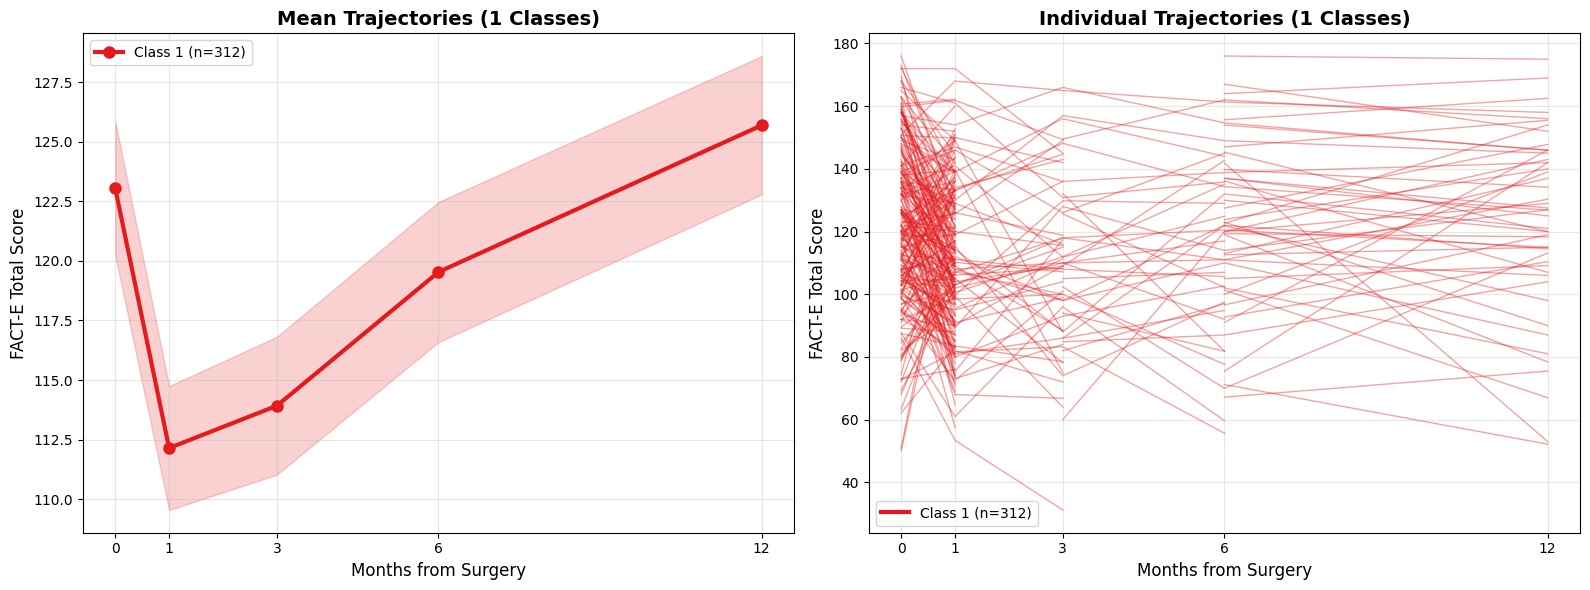


Plotting 2-class model:


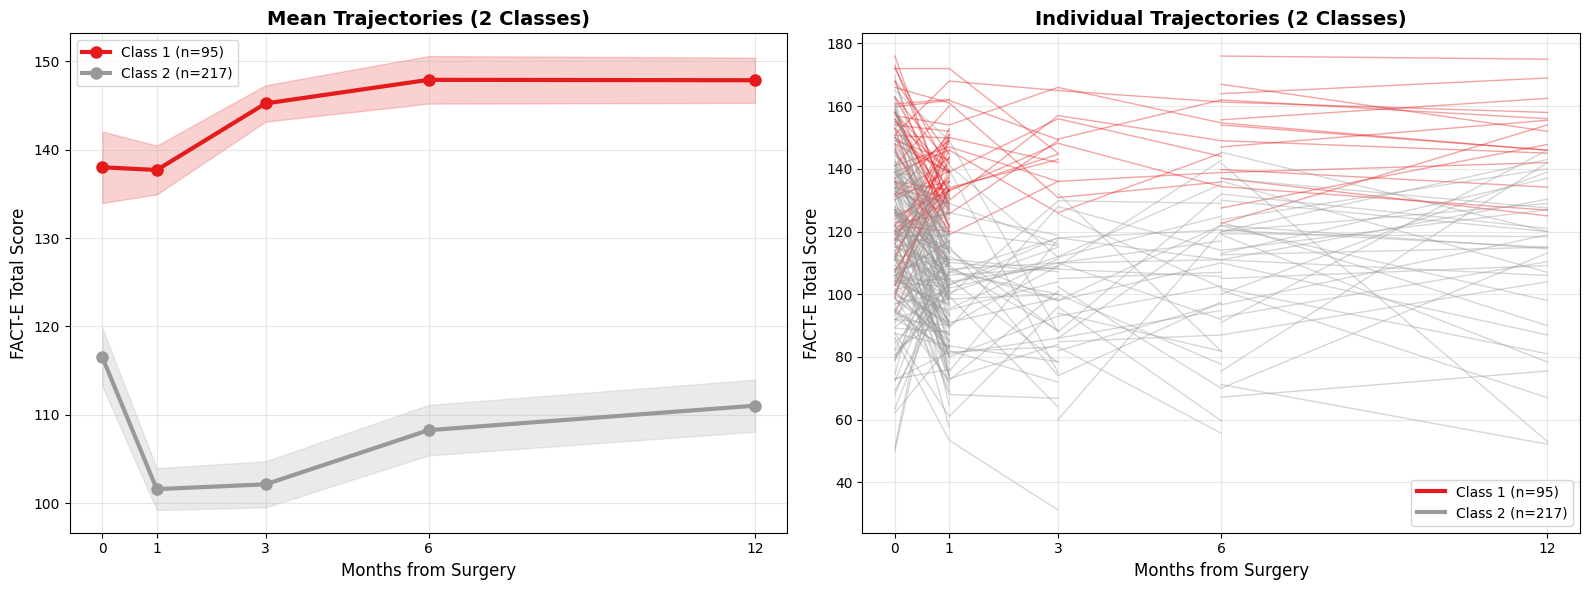


Plotting 3-class model:


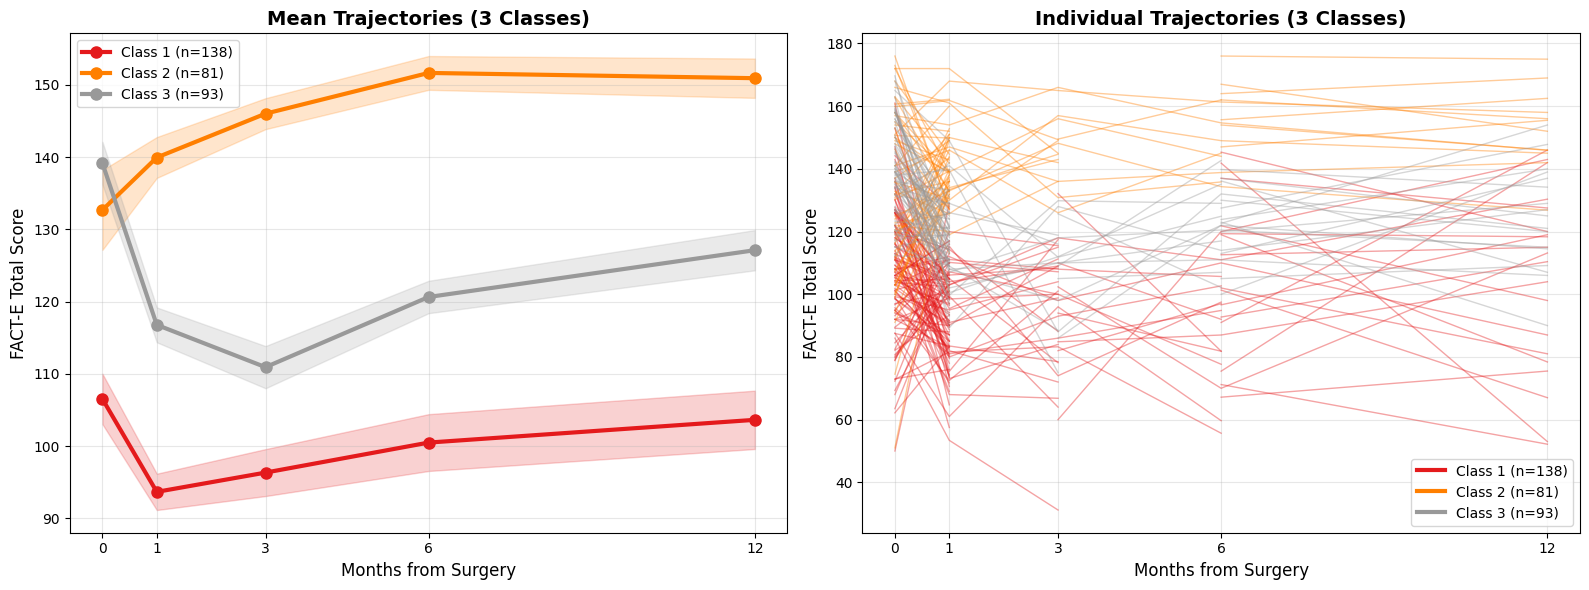


Plotting 4-class model:


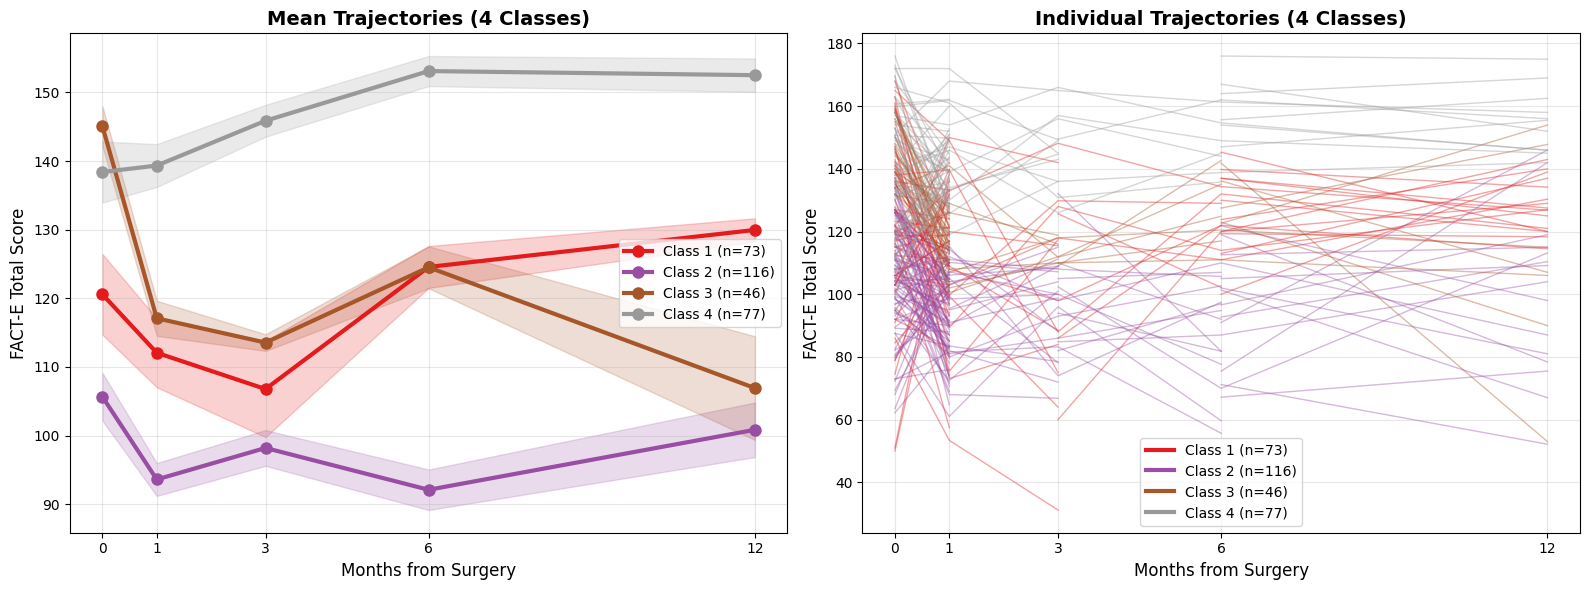

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stepmix.stepmix import StepMix
import warnings
warnings.filterwarnings('ignore')

def prepare_stepmix_data(score_comparison):
    """
    Prepare data for stepmix LCGM analysis in long format
    """
    data_list = []
    time_mapping = {'Baseline': 0, '1mo': 1, '3mo': 3, '6mo': 6, '12mo': 12}
    
    for patient_id in score_comparison.index:
        row = score_comparison.loc[patient_id]
        
        for timepoint, months in time_mapping.items():
            if timepoint != 'baseline_type':
                fact_e_score = row[timepoint] if pd.notna(row[timepoint]) else np.nan
                
                data_list.append({
                    'id': patient_id,
                    'time': months,
                    'time_sq': months**2,
                    'fact_e': fact_e_score,
                    'baseline_type': row['baseline_type']
                })
    
    trajectory_df = pd.DataFrame(data_list)
    
    # Prepare wide format for StepMix
    wide_data = []
    for patient_id in score_comparison.index:
        row = score_comparison.loc[patient_id]
        patient_row = [patient_id]
        
        # Add FACT-E scores for each timepoint
        for timepoint in ['Baseline', '1mo', '3mo', '6mo', '12mo']:
            if timepoint != 'baseline_type':
                score = row[timepoint] if pd.notna(row[timepoint]) else np.nan
                patient_row.append(score)
        
        wide_data.append(patient_row)
    
    wide_df = pd.DataFrame(wide_data, columns=['id', 'fact_e_0', 'fact_e_1', 'fact_e_3', 'fact_e_6', 'fact_e_12'])
    
    return trajectory_df, wide_df

def fit_lcgm_stepmix(score_comparison, n_classes_range=[1, 2, 3, 4]):
    """
    Fit LCGM models using StepMix - corrected version
    """
    trajectory_df, wide_df = prepare_stepmix_data(score_comparison)
    
    # For LCGM in StepMix, we don't need explicit time predictors
    # The Y matrix contains the repeated measures across time
    Y = wide_df[['fact_e_0', 'fact_e_1', 'fact_e_3', 'fact_e_6', 'fact_e_12']].values
    
    # X can be None for unconditional growth models, or just intercept
    X = None  # Let StepMix handle this internally
    
    models = {}
    results = {}
    
    for n_classes in n_classes_range:
        print(f"Fitting {n_classes}-class LCGM model...")
        
        # Fit StepMix model
        model = StepMix(
            n_components=n_classes,
            n_steps=1,
            measurement="continuous_nan",  # Handles missing values
            random_state=42,
            max_iter=1000,
            verbose=1
        )
        
        # Fit the model - pass only Y for unconditional model
        if X is None:
            model.fit(Y)
            # Get predictions
            labels = model.predict(Y)
            probabilities = model.predict_proba(Y)
            # Get fit statistics
            aic = model.aic(Y)
            bic = model.bic(Y)
        else:
            model.fit(X, Y)
            labels = model.predict(X, Y)
            probabilities = model.predict_proba(X, Y)
            aic = model.aic(X, Y)
            bic = model.bic(X, Y)
        
        # Calculate entropy and other statistics
        try:
            entropy = model.entropy_
        except AttributeError:
            # Calculate entropy manually
            entropy = -np.sum(probabilities * np.log(probabilities + 1e-10)) / len(probabilities)
            entropy = 1 - entropy / np.log(n_classes) if n_classes > 1 else 1.0
        
        # Average posterior probability
        avg_posterior_prob = np.mean(np.max(probabilities, axis=1))
        
        # Class sizes
        unique_labels, class_sizes = np.unique(labels, return_counts=True)
        class_size_dict = dict(zip(unique_labels, class_sizes))
        
        models[n_classes] = {
            'model': model,
            'labels': labels,
            'probabilities': probabilities,
            'patient_ids': wide_df['id'].values,
            'Y': Y
        }
        
        results[n_classes] = {
            'n_classes': n_classes,
            'AIC': aic,
            'BIC': bic,
            'Entropy': entropy,
            'AvePP': avg_posterior_prob,
            'Class_Sizes': class_size_dict,
            'N_Patients': len(wide_df)
        }
    
    return models, results, trajectory_df

def plot_trajectories(models, results, trajectory_df, n_classes):
    """
    Plot mean trajectories and spaghetti plots for a specific model
    """
    if n_classes not in models:
        print(f"Model with {n_classes} classes not found.")
        return
    
    model_info = models[n_classes]
    labels = model_info['labels']
    patient_ids = model_info['patient_ids']
    
    # Create patient-class mapping
    patient_class_map = dict(zip(patient_ids, labels))
    
    # Add class labels to trajectory data
    traj_df = trajectory_df.copy()
    traj_df['assigned_class'] = traj_df['id'].map(patient_class_map)
    traj_df = traj_df.dropna(subset=['assigned_class'])
    traj_df['assigned_class'] = traj_df['assigned_class'].astype(int)
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Colors for classes
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))
    
    # Plot 1: Mean trajectories with confidence intervals
    time_points = [0, 1, 3, 6, 12]
    
    for class_idx in range(n_classes):
        class_data = traj_df[traj_df['assigned_class'] == class_idx]
        
        means = []
        lower_ci = []
        upper_ci = []
        
        for time_point in time_points:
            time_data = class_data[class_data['time'] == time_point]['fact_e']
            
            if len(time_data) > 0:
                mean_val = time_data.mean()
                std_val = time_data.std()
                n_obs = len(time_data)
                ci = 1.96 * std_val / np.sqrt(n_obs) if n_obs > 1 else 0
                
                means.append(mean_val)
                lower_ci.append(mean_val - ci)
                upper_ci.append(mean_val + ci)
            else:
                means.append(np.nan)
                lower_ci.append(np.nan)
                upper_ci.append(np.nan)
        
        # Plot mean trajectory
        class_size = sum(labels == class_idx)
        ax1.plot(time_points, means, 'o-', color=colors[class_idx], 
                linewidth=3, markersize=8, 
                label=f'Class {class_idx+1} (n={class_size})')
        
        # Plot confidence intervals
        ax1.fill_between(time_points, lower_ci, upper_ci, 
                        color=colors[class_idx], alpha=0.2)
    
    ax1.set_xlabel('Months from Surgery', fontsize=12)
    ax1.set_ylabel('FACT-E Total Score', fontsize=12)
    ax1.set_title(f'Mean Trajectories ({n_classes} Classes)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(time_points)
    
    # Plot 2: Spaghetti plot
    for class_idx in range(n_classes):
        class_patients = patient_ids[labels == class_idx]
        
        for patient_id in class_patients:
            patient_data = traj_df[traj_df['id'] == patient_id]
            if len(patient_data) > 1:  # Only plot if multiple time points
                ax2.plot(patient_data['time'], patient_data['fact_e'], 
                        color=colors[class_idx], alpha=0.4, linewidth=1)
    
    ax2.set_xlabel('Months from Surgery', fontsize=12)
    ax2.set_ylabel('FACT-E Total Score', fontsize=12)
    ax2.set_title(f'Individual Trajectories ({n_classes} Classes)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(time_points)
    
    # Add legend for spaghetti plot
    for class_idx in range(n_classes):
        class_size = sum(labels == class_idx)
        ax2.plot([], [], color=colors[class_idx], linewidth=3, 
                label=f'Class {class_idx+1} (n={class_size})')
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def plot_all_models(models, results, trajectory_df):
    """
    Generate plots for all fitted models
    """
    for n_classes in sorted(models.keys()):
        print(f"\nPlotting {n_classes}-class model:")
        plot_trajectories(models, results, trajectory_df, n_classes)

def assign_patients_to_classes(models, results):
    """
    Create dataframe with patient class assignments for all models
    """
    assignments = {}
    
    for n_classes in models:
        model_info = models[n_classes]
        patient_ids = model_info['patient_ids']
        labels = model_info['labels']
        probabilities = model_info['probabilities']
        
        assignment_df = pd.DataFrame({
            'patient_id': patient_ids,
            'assigned_class': labels,
            'max_probability': np.max(probabilities, axis=1)
        })
        
        # Add individual class probabilities
        for i in range(n_classes):
            assignment_df[f'prob_class_{i+1}'] = probabilities[:, i]
        
        assignments[n_classes] = assignment_df
    
    return assignments



def print_model_comparison_stepmix(results):
    """Print model comparison table"""
    comparison_df = pd.DataFrame(results).T
    comparison_df = comparison_df[['n_classes', 'AIC', 'BIC', 'Entropy', 'AvePP', 'Class_Sizes', 'N_Patients']]
    
    print("\n" + "="*80)
    print("MIXTURE MODEL COMPARISON")
    print("="*80)
    print(f"{'Classes':<8} {'AIC':<12} {'BIC':<12} {'Entropy':<10} {'AvePP':<8} {'Class Sizes'}")
    print("-" * 80)
    
    for n_classes in sorted(results.keys()):
        result = results[n_classes]
        class_sizes_str = ', '.join([f"{k}:{v}" for k, v in result['Class_Sizes'].items()])
        print(f"{n_classes:<8} {result['AIC']:<12.2f} {result['BIC']:<12.2f} "
                f"{result['Entropy']:<10.3f} {result['AvePP']:<8.3f} {class_sizes_str}")
    
    print("-" * 80)
    print(f"Total Patients: {results[1]['N_Patients']}")
    print("="*80 + "\n")
    return comparison_df

# Run the complete analysis
print("Starting LCGM analysis with StepMix...")
models, results, trajectory_df = fit_lcgm_stepmix(score_comparison)
comparison_results = print_model_comparison_stepmix(results)

# Generate all plots
plot_all_models(models, results, trajectory_df)

# Get class assignments
class_assignments = assign_patients_to_classes(models, results)

### failed...

Starting LCGM Analysis...
LATENT CLASS GROWTH MODEL (LCGM) ANALYSIS
Note: This approach fits individual growth curves first, then uses mixture modeling
to identify classes of similar trajectories. This approximates flexmix approach.

Step 1: Preparing longitudinal data...
Long format data: 853 observations from 312 patients
Observations per patient: count    312.000000
mean       2.733974
std        0.839001
min        2.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        5.000000
dtype: float64

Step 2: Fitting individual growth curves...


Individual trajectories fitted for 312 patients

Step 3: Fitting LCGM models...

--- LINEAR LCGM ---
Using LINEAR trajectory features: ['intercept_linear', 'slope_linear']
Trajectory parameters matrix shape: (312, 2)
Feature statistics:
  intercept_linear: mean=120.652, std=23.285
  slope_linear: mean=-35.265, std=203.123

Fitting 1-class LINEAR LCGM...
Single class model (no mixture)
  AIC: 4.00, BIC: 11.49, Entropy: 1.000, AvePP: 1.000
  Class sizes: {0.0: 312}

Fitting 2-class LINEAR LCGM...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 77.39it/s, max_LL=-3.38e+3, max_avg_LL=-10.8]


MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag           
          class_no                          0          1
          param       variable                          
          covariances feature_0      712.3769   409.4878
                      feature_1    90010.8557  1019.8621
          means       feature_0      119.8710   121.2576
                      feature_1      -77.6259    -2.4453
    Class weights
        Class 1 : 0.44
        Class 2 : 0.56
    Fit for 2 latent classes
    Estimation method             : 1-step
    Number of observations        : 312
    Number of latent classes      : 2
    Number of estimated parameters: 9
    Log-likelihood (LL)           : -3383.6951
    -2LL                          : 6767.3902
    Average LL                    : -10.8452
    AIC                           : 6785.39
    BIC                           : 6819.08
    CAIC                          : 6828.08
    Sample-Size Adjusted BIC     

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 14.96it/s, max_LL=-3.36e+3, max_avg_LL=-10.8]


...

MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag            
          class_no                          0           1
          param       variable                           
          covariances feature_0      519.9032    710.9220
                      feature_1    92650.2090  80529.2068
                      feature_2   558308.8828      0.0000
          means       feature_0      122.4962    121.6154
                      feature_1      -81.1928    -63.0381
                      feature_2      137.9088      0.0000
    Class weights
        Class 1 : 0.52
        Class 2 : 0.48
    Fit for 2 latent classes
    Estimation method             : 1-step
    Number of observations        : 312
    Number of latent classes      : 2
    Number of estimated parameters: 13
    Log-likelihood (LL)           : -4277.4691
    -2LL                          : 8554.9383
    Average LL                    : -13.7098
    AIC                           : 8580.

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 77.02it/s, max_LL=-4.13e+3, max_avg_LL=-13.2]


MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag                        
          class_no                          0           1           2
          param       variable                                       
          covariances feature_0  7.011185e+02    710.9227    447.1243
                      feature_1  2.730147e+05  80529.4149  16368.7693
                      feature_2  1.823853e+06      0.0000  31056.7614
          means       feature_0  1.209811e+02    121.6154    123.0941
                      feature_1 -1.774644e+02    -63.0384    -43.1992
                      feature_2  3.626865e+02      0.0000     49.2006
    Class weights
        Class 1 : 0.15
        Class 2 : 0.48
        Class 3 : 0.37
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 312
    Number of latent classes      : 3
    Number of estimated parameters: 20
    Log-likelihood (LL)           : -4131.4342
 

Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00, 49.31it/s, max_LL=-4.07e+3, max_avg_LL=-13]


MODEL REPORT
    Measurement model parameters
          model_name            gaussian_diag                                     
          class_no                          0          1           2             3
          param       variable                                                    
          covariances feature_0      357.3413   402.9345    710.9228  7.312969e+02
                      feature_1     5618.2107  3864.9715  80529.4348  2.680559e+05
                      feature_2    14073.1460  5509.6685      0.0000  1.779207e+06
          means       feature_0      130.7595   117.7098    121.6155  1.191611e+02
                      feature_1     -165.3481    46.8269    -63.0388 -1.455883e+02
                      feature_2      210.3217   -53.5285      0.0000  2.941697e+02
    Class weights
        Class 1 : 0.17
        Class 2 : 0.19
        Class 3 : 0.48
        Class 4 : 0.15
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observation

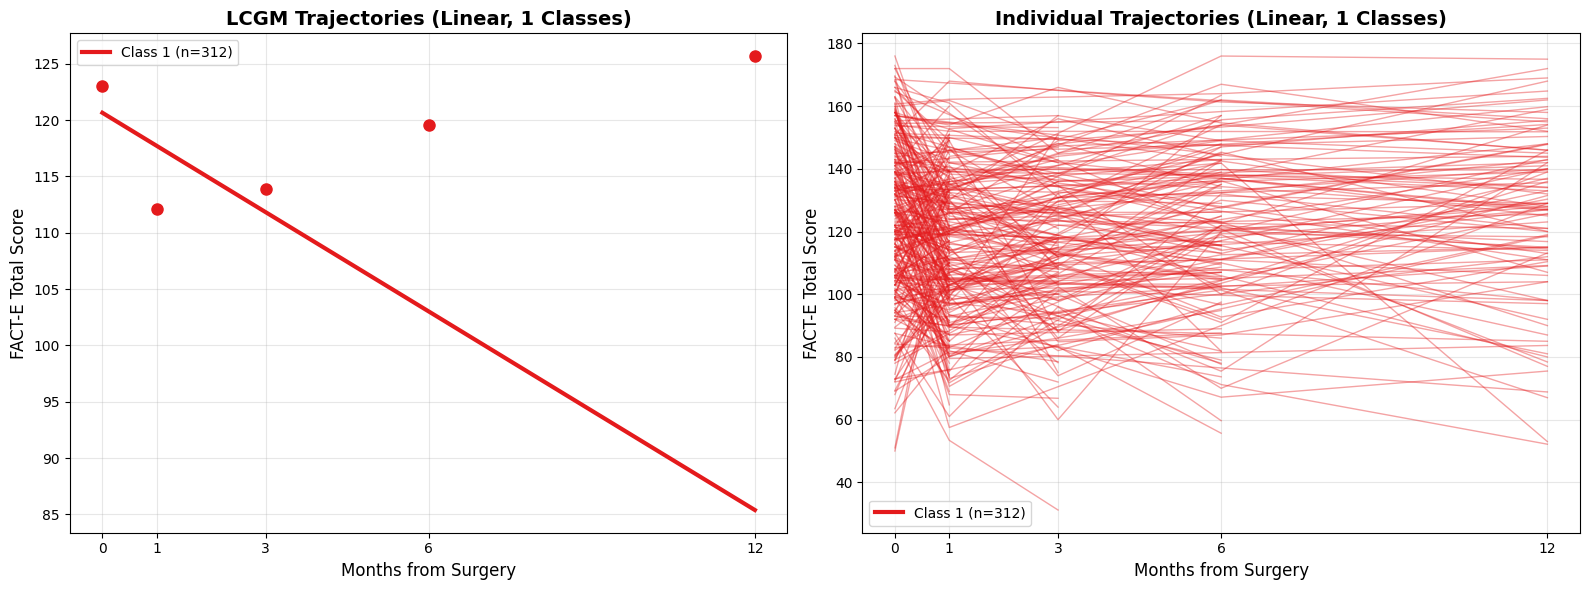


Quadratic LCGM - 1 classes:


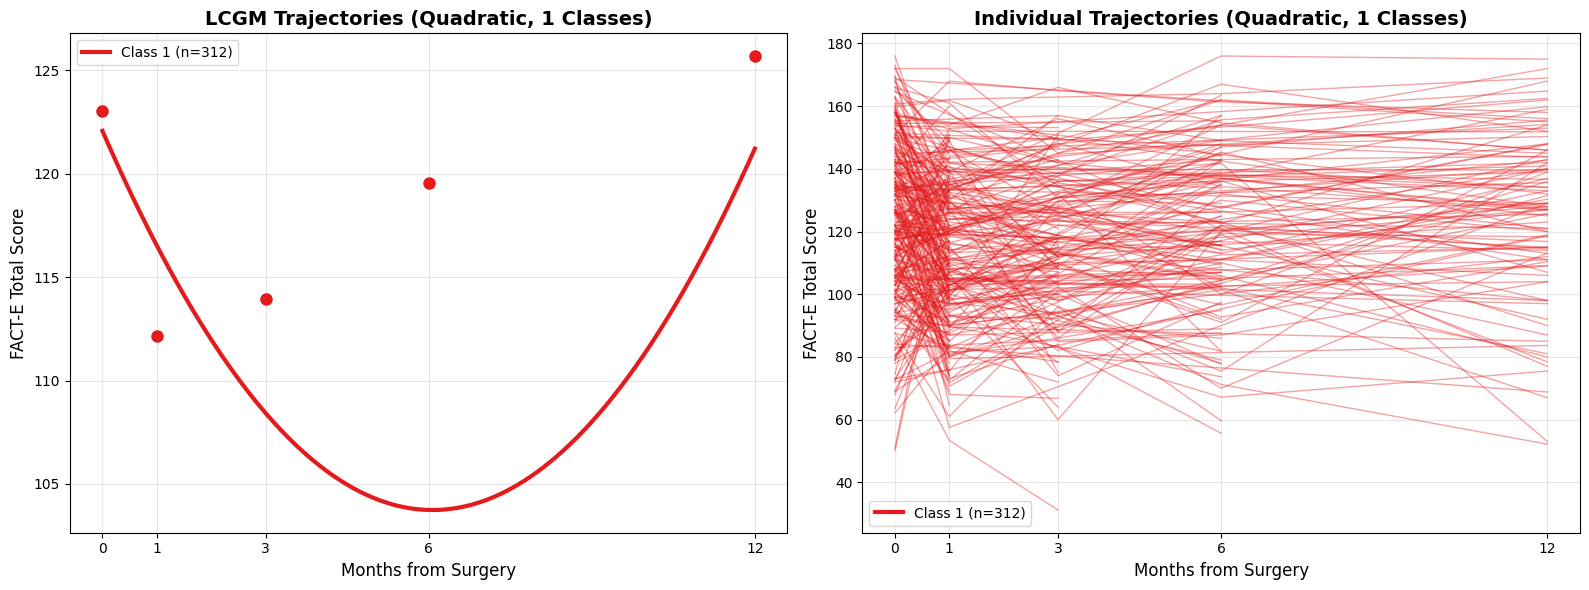


Linear LCGM - 2 classes:


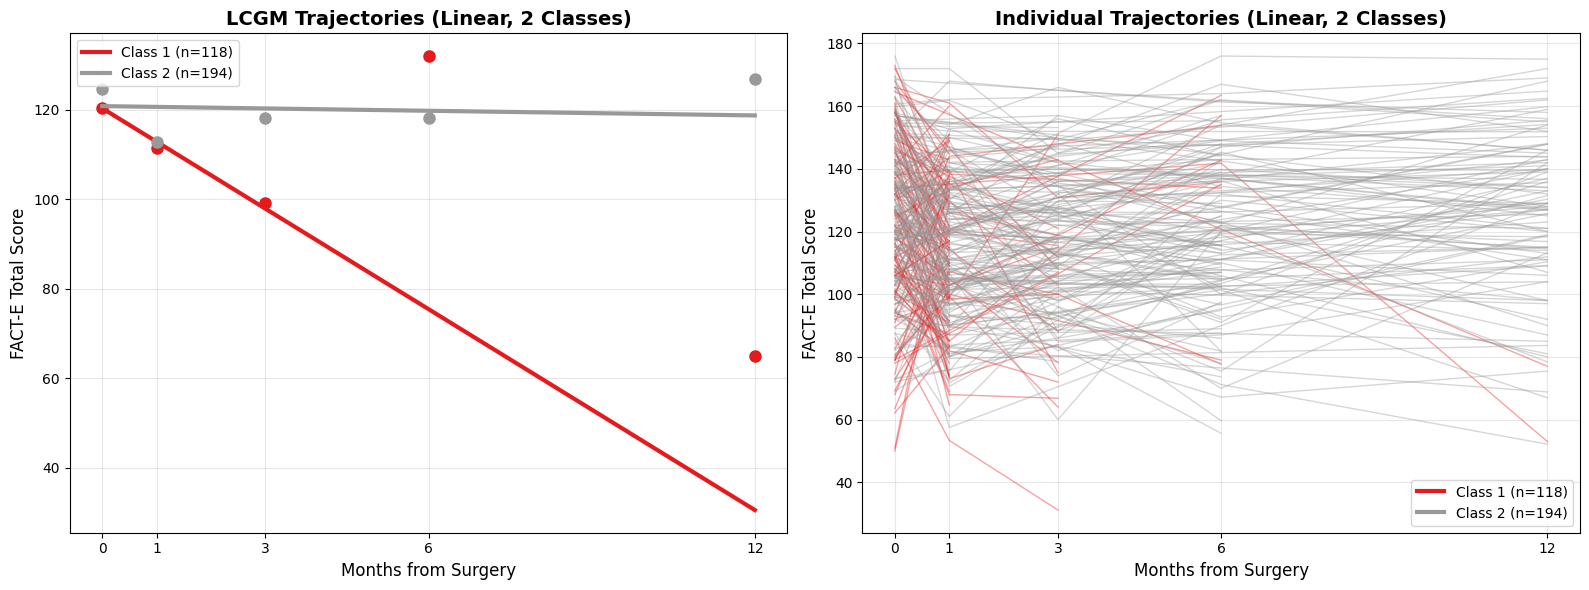


Quadratic LCGM - 2 classes:


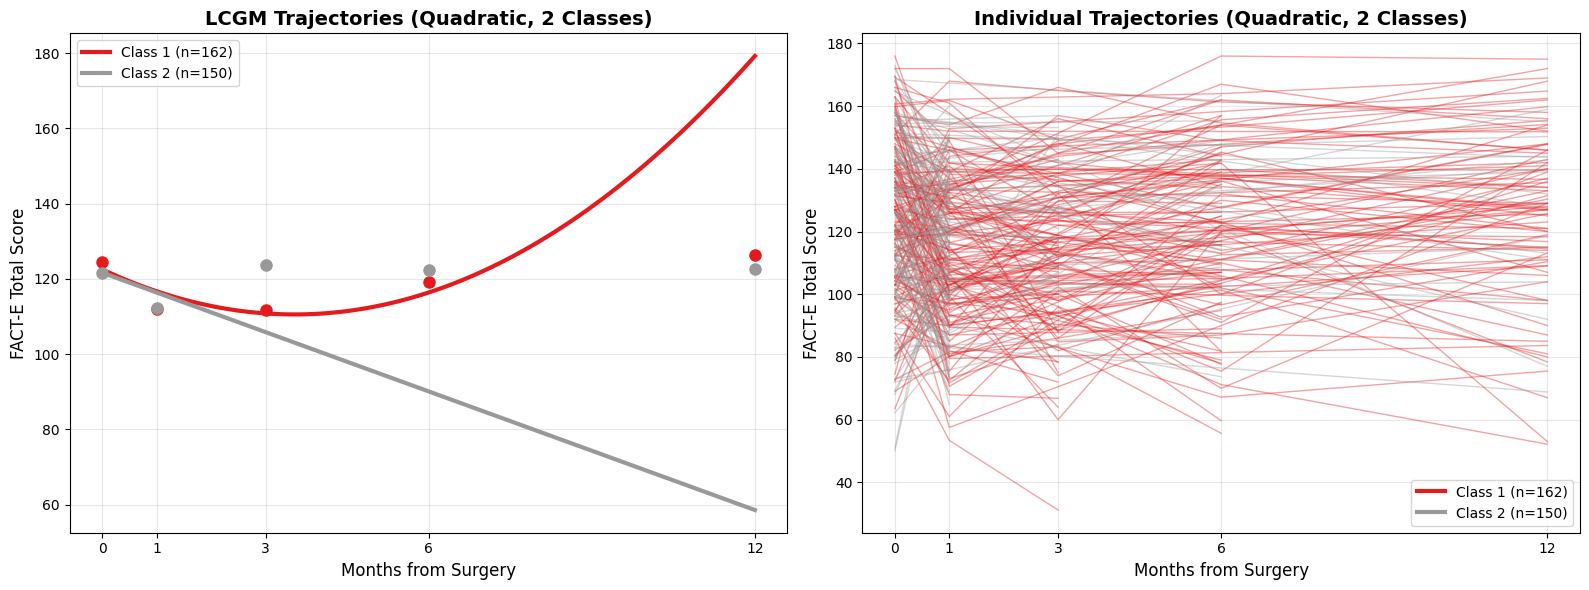


Linear LCGM - 3 classes:


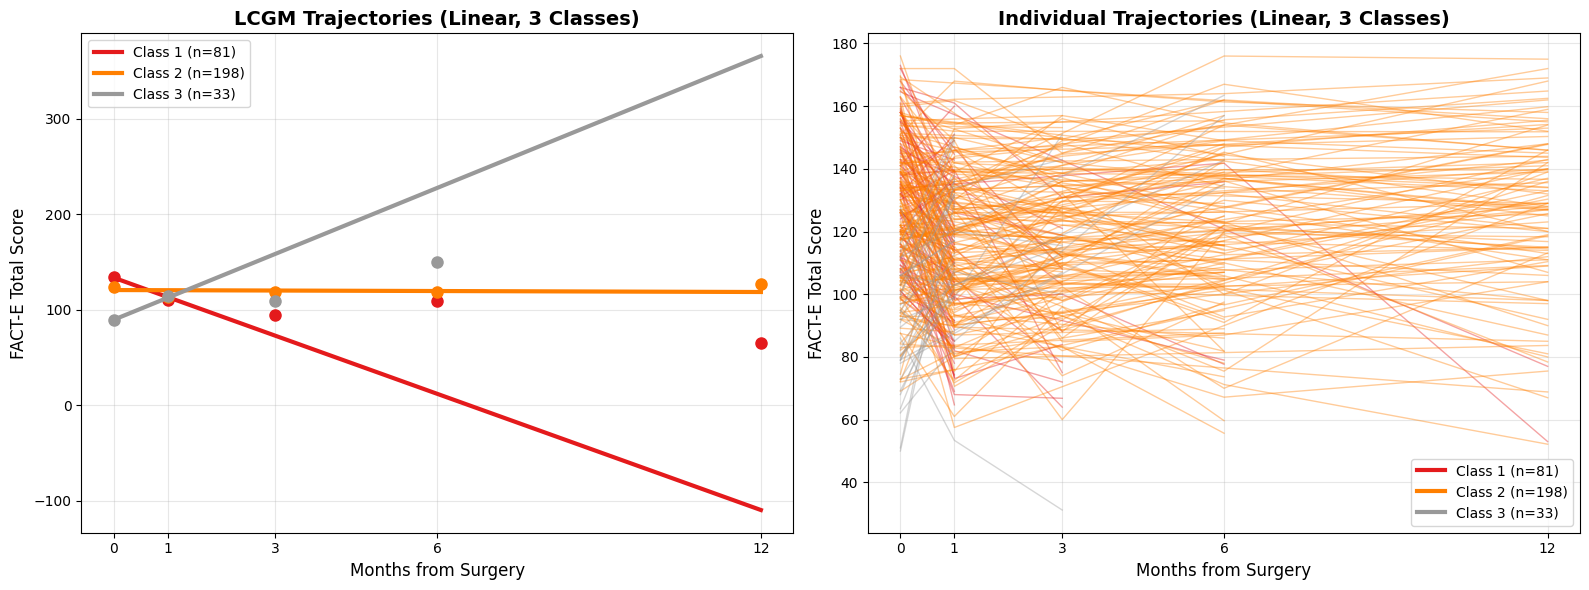


Quadratic LCGM - 3 classes:


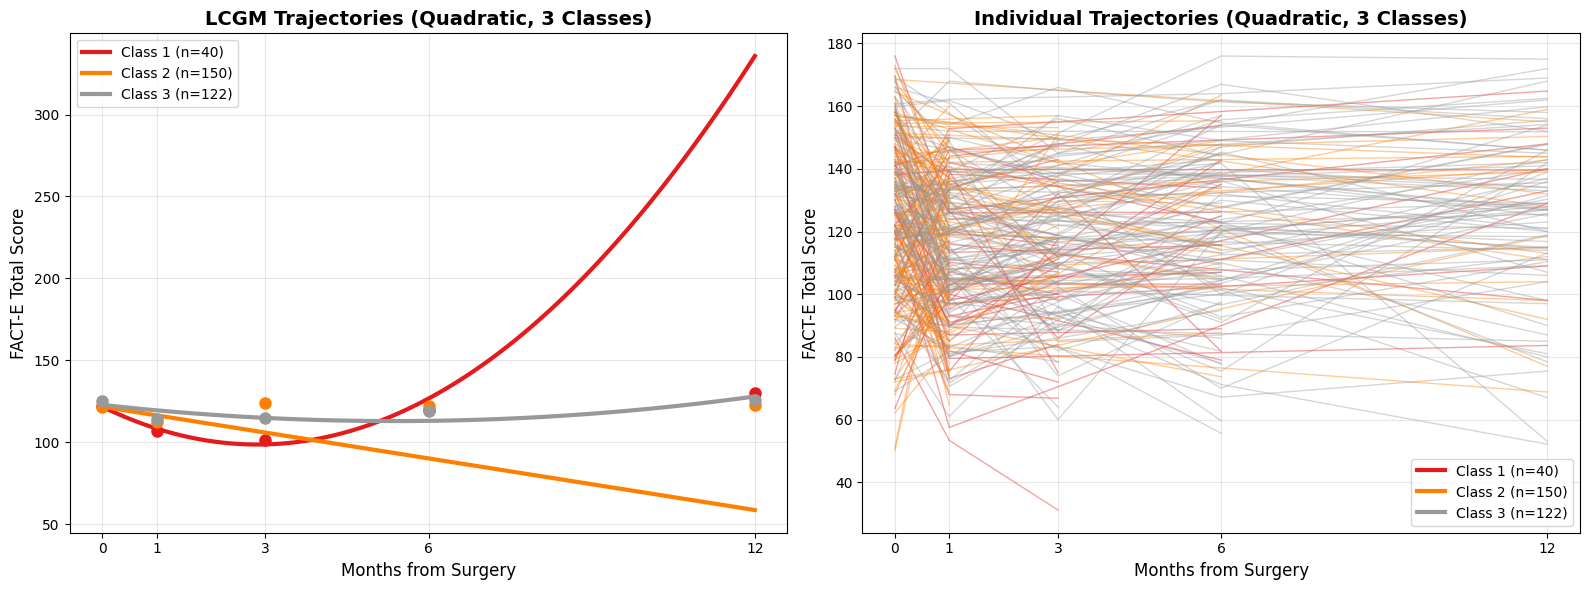


Linear LCGM - 4 classes:


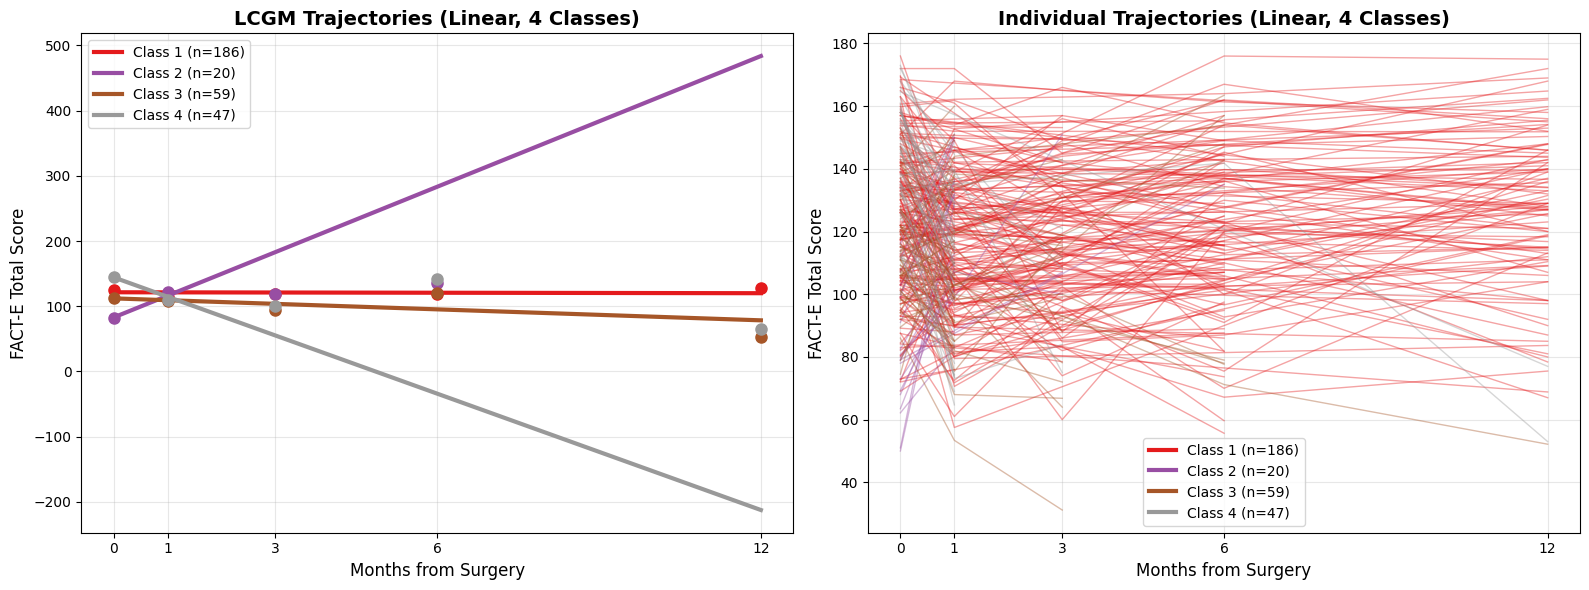


Quadratic LCGM - 4 classes:


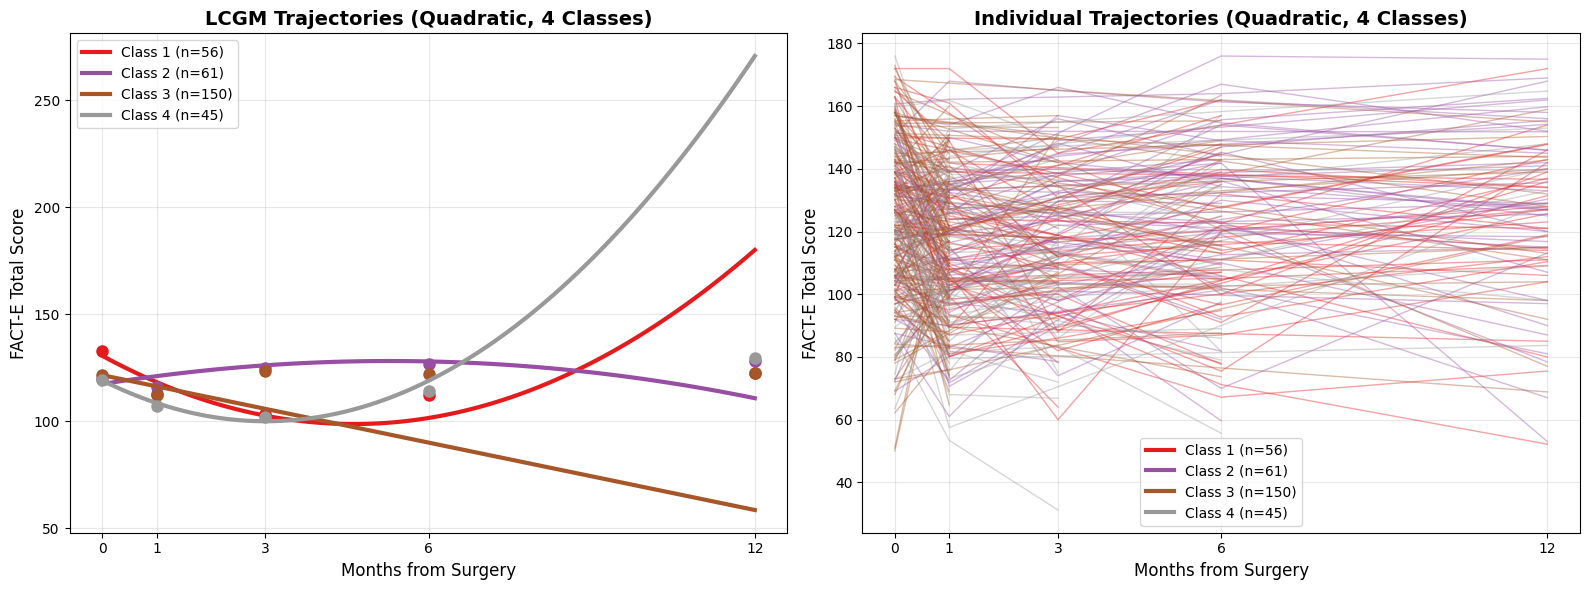


LCGM ANALYSIS COMPLETE!
This implements proper LCGM by:
1. Fitting individual growth curves (linear and quadratic)
2. Using mixture modeling to identify trajectory classes
3. Handling missing data by using available observations for each patient
4. Providing model comparison statistics and visualizations

Results available in lcgm_results dictionary with keys:
  - long_data
  - trajectory_params
  - linear_models
  - linear_results
  - linear_assignments
  - quad_models
  - quad_results
  - quad_assignments


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from stepmix.stepmix import StepMix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

def prepare_lcgm_long_format(score_comparison):
    """
    Prepare data in long format for proper LCGM analysis
    This mimics the R approach: fact_e ~ time (+ time^2)
    """
    data_list = []
    time_mapping = {'Baseline': 0, '1mo': 1, '3mo': 3, '6mo': 6, '12mo': 12}
    
    for patient_id in score_comparison.index:
        row = score_comparison.loc[patient_id]
        
        for timepoint, months in time_mapping.items():
            fact_e_score = row[timepoint] if pd.notna(row[timepoint]) else np.nan
            
            # Only include non-missing observations (similar to R filtering)
            if pd.notna(fact_e_score):
                data_list.append({
                    'id': patient_id,
                    'time': months / 12,  # Scale to 0-1 for numerical stability
                    'time_sq': (months / 12) ** 2,
                    'time_months': months,
                    'fact_e': fact_e_score,
                    'baseline_type': row['baseline_type']
                })
    
    long_df = pd.DataFrame(data_list)
    return long_df

def create_individual_trajectories(long_df):
    """
    Create individual trajectory parameters for each patient
    This approximates LCGM by fitting individual growth curves first
    """
    trajectory_params = []
    
    for patient_id in long_df['id'].unique():
        patient_data = long_df[long_df['id'] == patient_id].copy()
        
        if len(patient_data) >= 2:  # Need at least 2 points for trajectory
            # Linear trajectory
            X_linear = patient_data[['time']].values
            X_linear = np.column_stack([np.ones(len(X_linear)), X_linear])  # Add intercept
            y = patient_data['fact_e'].values
            
            try:
                linear_params = np.linalg.lstsq(X_linear, y, rcond=None)[0]
                intercept_linear = linear_params[0]
                slope_linear = linear_params[1]
                
                # Linear model fit
                y_pred_linear = X_linear @ linear_params
                mse_linear = mean_squared_error(y, y_pred_linear)
            except:
                intercept_linear = patient_data['fact_e'].iloc[0]
                slope_linear = 0
                mse_linear = np.inf
            
            # Quadratic trajectory (if >= 3 points)
            if len(patient_data) >= 3:
                X_quad = patient_data[['time', 'time_sq']].values
                X_quad = np.column_stack([np.ones(len(X_quad)), X_quad])  # Add intercept
                
                try:
                    quad_params = np.linalg.lstsq(X_quad, y, rcond=None)[0]
                    intercept_quad = quad_params[0]
                    slope_quad = quad_params[1]
                    quadratic_quad = quad_params[2]
                    
                    # Quadratic model fit
                    y_pred_quad = X_quad @ quad_params
                    mse_quad = mean_squared_error(y, y_pred_quad)
                except:
                    intercept_quad = intercept_linear
                    slope_quad = slope_linear
                    quadratic_quad = 0
                    mse_quad = mse_linear
            else:
                intercept_quad = intercept_linear
                slope_quad = slope_linear
                quadratic_quad = 0
                mse_quad = mse_linear
            
            trajectory_params.append({
                'id': patient_id,
                'n_obs': len(patient_data),
                'baseline_score': patient_data['fact_e'].iloc[0],
                'final_score': patient_data['fact_e'].iloc[-1],
                'change_score': patient_data['fact_e'].iloc[-1] - patient_data['fact_e'].iloc[0],
                # Linear model parameters
                'intercept_linear': intercept_linear,
                'slope_linear': slope_linear,
                'mse_linear': mse_linear,
                # Quadratic model parameters
                'intercept_quad': intercept_quad,
                'slope_quad': slope_quad,
                'quadratic_quad': quadratic_quad,
                'mse_quad': mse_quad
            })
        else:
            # Single observation - set to baseline values
            baseline_score = patient_data['fact_e'].iloc[0]
            trajectory_params.append({
                'id': patient_id,
                'n_obs': len(patient_data),
                'baseline_score': baseline_score,
                'final_score': baseline_score,
                'change_score': 0,
                'intercept_linear': baseline_score,
                'slope_linear': 0,
                'mse_linear': 0,
                'intercept_quad': baseline_score,
                'slope_quad': 0,
                'quadratic_quad': 0,
                'mse_quad': 0
            })
    
    return pd.DataFrame(trajectory_params)

def fit_lcgm_on_trajectories(trajectory_params, model_type='linear', n_classes_range=[1, 2, 3, 4]):
    """
    Fit LCGM using mixture modeling on individual trajectory parameters
    This approximates the flexmix approach
    """
    if model_type == 'linear':
        # Use intercept and slope for linear growth curves
        feature_cols = ['intercept_linear', 'slope_linear']
        print(f"Using LINEAR trajectory features: {feature_cols}")
    else:  # quadratic
        # Use intercept, slope, and quadratic term for quadratic growth curves
        feature_cols = ['intercept_quad', 'slope_quad', 'quadratic_quad']
        print(f"Using QUADRATIC trajectory features: {feature_cols}")
    
    # Prepare feature matrix
    X = trajectory_params[feature_cols].values
    
    print(f"Trajectory parameters matrix shape: {X.shape}")
    print(f"Feature statistics:")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: mean={X[:, i].mean():.3f}, std={X[:, i].std():.3f}")
    
    models = {}
    results = {}
    
    for n_classes in n_classes_range:
        print(f"\nFitting {n_classes}-class {model_type.upper()} LCGM...")
        
        if n_classes == 1:
            # Single class - just compute statistics
            print("Single class model (no mixture)")
            
            # Calculate simple statistics
            log_likelihood = 0  # Placeholder
            aic = 2 * len(feature_cols)  # Placeholder
            bic = len(feature_cols) * np.log(len(X))  # Placeholder
            
            labels = np.zeros(len(X))
            probabilities = np.ones((len(X), 1))
            
        else:
            # Multi-class mixture model
            model = StepMix(
                n_components=n_classes,
                n_steps=1,
                measurement="continuous",  # No missing data in trajectory parameters
                random_state=42,
                max_iter=1000,
                verbose=1
            )
            
            # Fit the model
            model.fit(X)
            
            # Get predictions
            labels = model.predict(X)
            probabilities = model.predict_proba(X)
            
            # Get fit statistics
            aic = model.aic(X)
            bic = model.bic(X)
        
        # Calculate entropy and other statistics
        if n_classes > 1:
            prob_log_prob = probabilities * np.log(probabilities + 1e-10)
            entropy = 1 + np.sum(prob_log_prob, axis=1).mean() / np.log(n_classes)
        else:
            entropy = 1.0
        
        # Average posterior probability
        avg_posterior_prob = np.mean(np.max(probabilities, axis=1))
        
        # Class sizes
        unique_labels, class_sizes = np.unique(labels, return_counts=True)
        class_size_dict = dict(zip(unique_labels, class_sizes))
        
        if n_classes > 1:
            models[n_classes] = {
                'model': model,
                'labels': labels,
                'probabilities': probabilities,
                'patient_ids': trajectory_params['id'].values,
                'X': X,
                'trajectory_params': trajectory_params
            }
        else:
            models[n_classes] = {
                'model': None,
                'labels': labels,
                'probabilities': probabilities,
                'patient_ids': trajectory_params['id'].values,
                'X': X,
                'trajectory_params': trajectory_params
            }
        
        results[n_classes] = {
            'n_classes': n_classes,
            'AIC': aic,
            'BIC': bic,
            'Entropy': entropy,
            'AvePP': avg_posterior_prob,
            'Class_Sizes': class_size_dict,
            'N_Patients': len(trajectory_params)
        }
        
        print(f"  AIC: {aic:.2f}, BIC: {bic:.2f}, Entropy: {entropy:.3f}, AvePP: {avg_posterior_prob:.3f}")
        print(f"  Class sizes: {class_size_dict}")
    
    return models, results

def print_model_comparison_lcgm(results, model_type):
    """
    Print model comparison table for LCGM
    """
    comparison_df = pd.DataFrame(results).T
    comparison_df = comparison_df[['n_classes', 'AIC', 'BIC', 'Entropy', 'AvePP', 'Class_Sizes', 'N_Patients']]
    
    print("\n" + "="*80)
    print(f"LATENT CLASS GROWTH MODEL COMPARISON - {model_type.upper()}")
    print("="*80)
    print(f"{'Classes':<8} {'AIC':<12} {'BIC':<12} {'Entropy':<10} {'AvePP':<8} {'Class Sizes'}")
    print("-" * 80)
    
    for n_classes in sorted(results.keys()):
        result = results[n_classes]
        class_sizes_str = ', '.join([f"{k}:{v}" for k, v in result['Class_Sizes'].items()])
        
        print(f"{n_classes:<8} {result['AIC']:<12.2f} {result['BIC']:<12.2f} "
              f"{result['Entropy']:<10.3f} {result['AvePP']:<8.3f} {class_sizes_str}")
    
    print("-" * 80)
    print(f"Total Patients: {results[1]['N_Patients']}")
    print("="*80 + "\n")
    
    return comparison_df

def plot_lcgm_trajectories(models, results, long_df, model_type, n_classes):
    """
    Plot LCGM trajectories for a specific model
    """
    if n_classes not in models:
        print(f"Model with {n_classes} classes not found.")
        return
    
    model_info = models[n_classes]
    labels = model_info['labels']
    patient_ids = model_info['patient_ids']
    trajectory_params = model_info['trajectory_params']
    
    # Create patient-class mapping
    patient_class_map = dict(zip(patient_ids, labels))
    
    # Add class labels to long data
    plot_data = long_df.copy()
    plot_data['assigned_class'] = plot_data['id'].map(patient_class_map)
    plot_data = plot_data.dropna(subset=['assigned_class'])
    plot_data['assigned_class'] = plot_data['assigned_class'].astype(int)
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Colors for classes
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))
    
    # Plot 1: Mean trajectories with model-predicted curves
    time_points = np.linspace(0, 1, 100)  # Smooth curves
    time_months_smooth = time_points * 12
    
    for class_idx in range(n_classes):
        class_data = plot_data[plot_data['assigned_class'] == class_idx]
        class_params = trajectory_params[labels == class_idx]
        
        if len(class_params) > 0:
            # Calculate mean trajectory parameters for this class
            if model_type == 'linear':
                mean_intercept = class_params['intercept_linear'].mean()
                mean_slope = class_params['slope_linear'].mean()
                # Predicted trajectory
                predicted_scores = mean_intercept + mean_slope * time_points
            else:  # quadratic
                mean_intercept = class_params['intercept_quad'].mean()
                mean_slope = class_params['slope_quad'].mean()
                mean_quad = class_params['quadratic_quad'].mean()
                # Predicted trajectory
                predicted_scores = mean_intercept + mean_slope * time_points + mean_quad * (time_points ** 2)
            
            # Plot predicted curve
            class_size = len(class_params)
            ax1.plot(time_months_smooth, predicted_scores, '-', color=colors[class_idx], 
                    linewidth=3, label=f'Class {class_idx+1} (n={class_size})')
            
            # Plot observed means at actual timepoints
            obs_means = []
            obs_times = []
            for time_month in [0, 1, 3, 6, 12]:
                time_norm = time_month / 12
                time_data = class_data[abs(class_data['time'] - time_norm) < 0.01]['fact_e']
                if len(time_data) > 0:
                    obs_means.append(time_data.mean())
                    obs_times.append(time_month)
            
            if obs_means:
                ax1.plot(obs_times, obs_means, 'o', color=colors[class_idx], markersize=8)
    
    ax1.set_xlabel('Months from Surgery', fontsize=12)
    ax1.set_ylabel('FACT-E Total Score', fontsize=12)
    ax1.set_title(f'LCGM Trajectories ({model_type.title()}, {n_classes} Classes)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks([0, 1, 3, 6, 12])
    
    # Plot 2: Spaghetti plot of individual trajectories
    for class_idx in range(n_classes):
        class_patients = patient_ids[labels == class_idx]
        
        for patient_id in class_patients:
            patient_data = plot_data[plot_data['id'] == patient_id]
            if len(patient_data) > 1:  # Only plot if multiple time points
                ax2.plot(patient_data['time_months'], patient_data['fact_e'], 
                        color=colors[class_idx], alpha=0.4, linewidth=1)
    
    ax2.set_xlabel('Months from Surgery', fontsize=12)
    ax2.set_ylabel('FACT-E Total Score', fontsize=12)
    ax2.set_title(f'Individual Trajectories ({model_type.title()}, {n_classes} Classes)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks([0, 1, 3, 6, 12])
    
    # Add legend for spaghetti plot
    for class_idx in range(n_classes):
        class_size = sum(labels == class_idx)
        ax2.plot([], [], color=colors[class_idx], linewidth=3, 
                label=f'Class {class_idx+1} (n={class_size})')
    ax2.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return fig

def assign_patients_to_classes_lcgm(models, results):
    """
    Create dataframe with patient class assignments for LCGM models
    """
    assignments = {}
    
    for n_classes in models:
        model_info = models[n_classes]
        patient_ids = model_info['patient_ids']
        labels = model_info['labels']
        probabilities = model_info['probabilities']
        trajectory_params = model_info['trajectory_params']
        
        assignment_df = pd.DataFrame({
            'patient_id': patient_ids,
            'assigned_class': labels,
            'max_probability': np.max(probabilities, axis=1)
        })
        
        # Add individual class probabilities
        for i in range(n_classes):
            if probabilities.shape[1] > i:
                assignment_df[f'prob_class_{i+1}'] = probabilities[:, i]
            else:
                assignment_df[f'prob_class_{i+1}'] = 0.0
        
        # Add trajectory parameters
        trajectory_cols = ['n_obs', 'baseline_score', 'final_score', 'change_score',
                          'intercept_linear', 'slope_linear', 'intercept_quad', 'slope_quad', 'quadratic_quad']
        for col in trajectory_cols:
            if col in trajectory_params.columns:
                assignment_df[col] = trajectory_params[col].values
        
        assignments[n_classes] = assignment_df
    
    return assignments

# Main analysis function
def run_lcgm_analysis(score_comparison):
    """
    Run complete LCGM analysis
    """
    print("="*80)
    print("LATENT CLASS GROWTH MODEL (LCGM) ANALYSIS")
    print("="*80)
    print("Note: This approach fits individual growth curves first, then uses mixture modeling")
    print("to identify classes of similar trajectories. This approximates flexmix approach.")
    print()
    
    # Step 1: Prepare long format data
    print("Step 1: Preparing longitudinal data...")
    long_df = prepare_lcgm_long_format(score_comparison)
    print(f"Long format data: {len(long_df)} observations from {long_df['id'].nunique()} patients")
    print(f"Observations per patient: {long_df.groupby('id').size().describe()}")
    
    # Step 2: Create individual trajectory parameters
    print("\nStep 2: Fitting individual growth curves...")
    trajectory_params = create_individual_trajectories(long_df)
    print(f"Individual trajectories fitted for {len(trajectory_params)} patients")
    
    # Step 3: Fit LCGM models
    print("\nStep 3: Fitting LCGM models...")
    
    # Linear LCGM
    print("\n--- LINEAR LCGM ---")
    linear_models, linear_results = fit_lcgm_on_trajectories(trajectory_params, 'linear')
    linear_comparison = print_model_comparison_lcgm(linear_results, 'linear')
    
    # Quadratic LCGM
    print("\n--- QUADRATIC LCGM ---")
    quad_models, quad_results = fit_lcgm_on_trajectories(trajectory_params, 'quadratic')
    quad_comparison = print_model_comparison_lcgm(quad_results, 'quadratic')
    
    # Step 4: Generate plots
    print("\nStep 4: Generating plots...")
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes in linear_models:
            print(f"\nLinear LCGM - {n_classes} classes:")
            plot_lcgm_trajectories(linear_models, linear_results, long_df, 'linear', n_classes)
        
        if n_classes in quad_models:
            print(f"\nQuadratic LCGM - {n_classes} classes:")
            plot_lcgm_trajectories(quad_models, quad_results, long_df, 'quadratic', n_classes)
    
    # Step 5: Get class assignments
    linear_assignments = assign_patients_to_classes_lcgm(linear_models, linear_results)
    quad_assignments = assign_patients_to_classes_lcgm(quad_models, quad_results)
    
    return {
        'long_data': long_df,
        'trajectory_params': trajectory_params,
        'linear_models': linear_models,
        'linear_results': linear_results,
        'linear_assignments': linear_assignments,
        'quad_models': quad_models,
        'quad_results': quad_results,
        'quad_assignments': quad_assignments
    }

# Run the analysis
print("Starting LCGM Analysis...")
lcgm_results = run_lcgm_analysis(score_comparison)

print("\n" + "="*80)
print("LCGM ANALYSIS COMPLETE!")
print("="*80)
print("This implements proper LCGM by:")
print("1. Fitting individual growth curves (linear and quadratic)")
print("2. Using mixture modeling to identify trajectory classes")
print("3. Handling missing data by using available observations for each patient")
print("4. Providing model comparison statistics and visualizations")
print()
print("Results available in lcgm_results dictionary with keys:")
for key in lcgm_results.keys():
    print(f"  - {key}")

In [23]:
lcgm_results

{'long_data':        id      time   time_sq  time_months      fact_e       baseline_type
 0      27  0.000000  0.000000            0  132.000000      baseline_arm_1
 1      27  0.083333  0.006944            1  151.000000      baseline_arm_1
 2      32  0.000000  0.000000            0  117.500000      baseline_arm_1
 3      32  1.000000  1.000000           12  159.000000      baseline_arm_1
 4      76  0.000000  0.000000            0   95.000000  preoperative_arm_1
 ..    ...       ...       ...          ...         ...                 ...
 848  1743  0.250000  0.062500            3  126.666667      baseline_arm_1
 849  1752  0.000000  0.000000            0  172.000000  preoperative_arm_1
 850  1752  0.083333  0.006944            1  139.000000  preoperative_arm_1
 851  1770  0.000000  0.000000            0   96.636364  preoperative_arm_1
 852  1770  0.083333  0.006944            1  110.000000  preoperative_arm_1
 
 [853 rows x 6 columns],
 'trajectory_params':        id  n_obs  baseline

# Characteristic by class - 0) FACT E baseline 

In [73]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [74]:
print(score_comparison["Baseline"].describe())

count    312.000000
mean     123.045269
std       25.370178
min       50.000000
25%      105.475000
50%      123.666667
75%      141.750000
max      176.000000
Name: Baseline, dtype: float64


In [75]:
def create_baseline_summary_all_models_facte(class_assignments, score_comparison):
    """
    Create baseline FACT-E summary for all class solutions (1-4 classes)
    """
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
            
        assignments = class_assignments[n_classes].copy()
        merged = assignments.merge(
            score_comparison[['Baseline']], 
            left_on='patient_id', 
            right_index=True, 
            how='left'
        )
        
        summary_rows = []
        for class_idx in range(n_classes):
            class_data = merged[merged['assigned_class'] == class_idx]
            baseline_facte = class_data['Baseline'].dropna()
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': len(class_data),
                'Mean': baseline_facte.mean() if len(baseline_facte) > 0 else np.nan,
                'SD': baseline_facte.std() if len(baseline_facte) > 0 else np.nan,
                'Missing': len(class_data) - len(baseline_facte)
            })
        
        # Overall row - using same logic
        baseline_overall = merged['Baseline'].dropna()
        summary_rows.append({
            'Class': 'Overall',
            'N': len(merged),
            'Mean': baseline_overall.mean() if len(baseline_overall) > 0 else np.nan,
            'SD': baseline_overall.std() if len(baseline_overall) > 0 else np.nan,
            'Missing': len(merged) - len(baseline_overall)
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
baseline_summaries = create_baseline_summary_all_models_facte(class_assignments, score_comparison)

# Display results
for n_classes, df in baseline_summaries.items():
    print(f"\n{n_classes}-Class Solution - Baseline FACT-E")
    print("="*60)
    for _, row in df.iterrows():
        if pd.notna(row['Mean']):
            print(f"Class {row['Class']}: n={row['N']:<3} Mean={row['Mean']:.1f} (SD={row['SD']:.1f}), Missing={row['Missing']:.0f}")
        else:
            print(f"Class {row['Class']}: n={row['N']:<3} No baseline data")
    print()


1-Class Solution - Baseline FACT-E
Class 1: n=312 Mean=123.0 (SD=25.4), Missing=0
Class Overall: n=312 Mean=123.0 (SD=25.4), Missing=0


2-Class Solution - Baseline FACT-E
Class 1: n=95  Mean=138.0 (SD=20.1), Missing=0
Class 2: n=217 Mean=116.5 (SD=24.7), Missing=0
Class Overall: n=312 Mean=123.0 (SD=25.4), Missing=0


3-Class Solution - Baseline FACT-E
Class 1: n=138 Mean=106.5 (SD=20.9), Missing=0
Class 2: n=81  Mean=132.7 (SD=25.4), Missing=0
Class 3: n=93  Mean=139.2 (SD=14.5), Missing=0
Class Overall: n=312 Mean=123.0 (SD=25.4), Missing=0


4-Class Solution - Baseline FACT-E
Class 1: n=73  Mean=120.6 (SD=25.6), Missing=0
Class 2: n=116 Mean=105.7 (SD=19.2), Missing=0
Class 3: n=46  Mean=145.1 (SD=10.1), Missing=0
Class 4: n=77  Mean=138.4 (SD=19.9), Missing=0
Class Overall: n=312 Mean=123.0 (SD=25.4), Missing=0



# Characteristic by class - 1) BMI 

In [72]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [107]:
def create_baseline_summary_all_models_bmi(class_assignments, score_comparison, filtered_df):
    """
    Create BMI summary for all class solutions (1-4 classes)
    """
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        assignments = class_assignments[n_classes].copy()
        
        # Merge with filtered_df to get BMI
        merged = assignments.merge(
            filtered_df[["id", "bmi"]],
            left_on='patient_id',
            right_on='id',
            how='left'
        )
        
        # Calculate median BMI from all non-missing values
        median_bmi = merged['bmi'].median()
        
        # Find patient IDs where all BMI values are missing
        patients_all_missing = merged.groupby('patient_id')['bmi'].apply(lambda x: x.isna().all())
        patients_to_impute = patients_all_missing[patients_all_missing].index
        
        # Impute BMI for those patients
        mask = merged['patient_id'].isin(patients_to_impute)
        merged.loc[mask, 'bmi'] = median_bmi
        print(f"{n_classes}-Class: Imputed {len(patients_to_impute)} missing patients with median BMI: {median_bmi:.2f}")
        
        # Replace BMI outliers with median (outside range 7-186)
        outlier_mask = (merged['bmi'] < 7) | (merged['bmi'] > 186)
        outlier_unique_patients = merged.loc[outlier_mask, 'patient_id'].nunique()
        outlier_count = outlier_mask.sum()
        merged.loc[outlier_mask, 'bmi'] = median_bmi
        print(f"{n_classes}-Class: Replaced {outlier_count} outlier BMI values from {outlier_unique_patients} unique patients with median BMI: {median_bmi:.2f}")
                
        # Remove NA and duplicates (critical because filtered_df has multiple rows per patient)
        merged_clean = merged.dropna(subset=["bmi"])
        merged_clean = merged_clean.drop_duplicates()
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = merged_clean[merged_clean['assigned_class'] == class_idx]
            bmi_data = class_data['bmi'].dropna()
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': len(class_data),
                'Mean': bmi_data.mean() if len(bmi_data) > 0 else np.nan,
                'SD': bmi_data.std() if len(bmi_data) > 0 else np.nan,
                'Missing': len(class_data) - len(bmi_data)
            })
        
        # Overall row
        bmi_overall = merged_clean['bmi'].dropna()
        summary_rows.append({
            'Class': 'Overall',
            'N': len(merged_clean),
            'Mean': bmi_overall.mean() if len(bmi_overall) > 0 else np.nan,
            'SD': bmi_overall.std() if len(bmi_overall) > 0 else np.nan,
            'Missing': len(merged_clean) - len(bmi_overall)
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

bmi_summaries = create_baseline_summary_all_models_bmi(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in bmi_summaries.items():
    print(f"\n{n_classes}-Class Solution - BMI")
    print("="*60)
    for _, row in df.iterrows():
        if pd.notna(row['Mean']):
            print(f"Class {row['Class']}: n={row['N']:<3} Mean={row['Mean']:.1f} (SD={row['SD']:.1f}), Missing={row['Missing']:.0f}")
        else:
            print(f"Class {row['Class']}: n={row['N']:<3} No BMI data")
    print()

1-Class: Imputed 18 missing patients with median BMI: 26.00
1-Class: Replaced 9 outlier BMI values from 9 unique patients with median BMI: 26.00
2-Class: Imputed 18 missing patients with median BMI: 26.00
2-Class: Replaced 9 outlier BMI values from 9 unique patients with median BMI: 26.00
3-Class: Imputed 18 missing patients with median BMI: 26.00
3-Class: Replaced 9 outlier BMI values from 9 unique patients with median BMI: 26.00
4-Class: Imputed 18 missing patients with median BMI: 26.00
4-Class: Replaced 9 outlier BMI values from 9 unique patients with median BMI: 26.00

1-Class Solution - BMI
Class 1: n=312 Mean=26.5 (SD=5.5), Missing=0
Class Overall: n=312 Mean=26.5 (SD=5.5), Missing=0


2-Class Solution - BMI
Class 1: n=95  Mean=26.9 (SD=6.0), Missing=0
Class 2: n=217 Mean=26.3 (SD=5.3), Missing=0
Class Overall: n=312 Mean=26.5 (SD=5.5), Missing=0


3-Class Solution - BMI
Class 1: n=138 Mean=26.1 (SD=5.5), Missing=0
Class 2: n=81  Mean=26.2 (SD=4.8), Missing=0
Class 3: n=93  Mean

# Characteristic by class - 2) smoking

In [21]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [22]:
def create_baseline_summary_all_models_smoking(class_assignments, score_comparison, filtered_df):
    """
    Create smoking summary for all class solutions (1-4 classes)
    Smoking is categorical: 0=Never, 1=Ever (collapsed from 1,2,3), 9999=Unknown (then imputed with MICE)
    """
    import miceforest as mf
    
    # ========== RUN MICE ONCE OUTSIDE THE LOOP ==========
    print("Preparing smoking data for MICE imputation...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()  # Use 1-class solution for all patients
    
    # Merge with filtered_df to get smoking
    smoking_prep = pd.DataFrame({'patient_id': all_patient_ids})
    smoking_prep = smoking_prep.merge(
        filtered_df[["id", "smoking"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    # Find patient IDs where all smoking values are missing
    patients_all_missing = smoking_prep.groupby('patient_id')['smoking'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute smoking for those patients with 9999 (unknown)
    mask = smoking_prep['patient_id'].isin(patients_to_impute)
    smoking_prep.loc[mask, 'smoking'] = 9999.0
    print(f"Imputed {len(patients_to_impute)} unique patients with smoking=9999 (unknown)")
    
    # Remove NA and duplicates
    smoking_prep_clean = smoking_prep.dropna(subset=["smoking"])
    smoking_prep_clean = smoking_prep_clean.drop_duplicates()
    
    # Collapse smoking variable
    smoking_prep_clean['smoking_collapsed'] = smoking_prep_clean['smoking'].copy()
    smoking_prep_clean.loc[smoking_prep_clean['smoking'].isin([1, 2, 3]), 'smoking_collapsed'] = 1  # Ever Smoked
    smoking_prep_clean.loc[smoking_prep_clean['smoking'] == 0, 'smoking_collapsed'] = 0  # Never Smoked
    smoking_prep_clean.loc[smoking_prep_clean['smoking'] == 9999, 'smoking_collapsed'] = 9999  # Unknown
    
    print("Smoking collapsed - Value counts:")
    print(smoking_prep_clean['smoking_collapsed'].value_counts())
    
    # Perform MICE imputation ONCE
    print("\nPerforming MICE imputation for smoking=9999...")
    
    # Replace 9999 with NaN for imputation
    smoking_prep_clean['smoking_collapsed_for_imputation'] = smoking_prep_clean['smoking_collapsed'].replace(9999, np.nan)
    
    # Merge baseline FACT-E for imputation model
    smoking_prep_clean = smoking_prep_clean.merge(
        score_comparison[['Baseline']],
        left_on='patient_id',
        right_index=True,
        how='left'
    )
    
    print(f"Running MICE on {len(smoking_prep_clean)} unique patients")
    
    # Create dataset for MICE
    mice_data = smoking_prep_clean[['smoking_collapsed_for_imputation', 'Baseline']].copy()
    
    # MICE imputation
    mice_imputer = mf.ImputationKernel(
        mice_data,
        datasets=1,
        random_state=42
    )
    
    mice_imputer.mice(iterations=1, verbose=True)
    
    # Get completed dataset
    completed_data = mice_imputer.complete_data(0)
    
    # Extract imputed values
    imputed_smoking = completed_data['smoking_collapsed_for_imputation'].round().astype(int)
    
    # Create mapping dictionary for all patients
    smoking_imputation_map = dict(zip(smoking_prep_clean['patient_id'], imputed_smoking))
    
    print("Smoking after MICE imputation - Value counts:")
    print(pd.Series(imputed_smoking).value_counts())
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the pre-computed imputed smoking values
        assignments['smoking_collapsed_imputed'] = assignments['patient_id'].map(smoking_imputation_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            smoking_data = class_data['smoking_collapsed_imputed'].dropna()
            
            # Count each category
            n_never = (smoking_data == 0).sum()
            n_ever = (smoking_data == 1).sum()
            
            # Calculate proportions
            total = len(smoking_data)
            prop_never = (n_never / total * 100) if total > 0 else 0
            prop_ever = (n_ever / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'Never_n': n_never,
                'Never_%': prop_never,
                'Ever_n': n_ever,
                'Ever_%': prop_ever,
                'Mean': smoking_data.mean() if total > 0 else np.nan,
                'SD': smoking_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        smoking_overall = assignments['smoking_collapsed_imputed'].dropna()
        n_never_overall = (smoking_overall == 0).sum()
        n_ever_overall = (smoking_overall == 1).sum()
        total_overall = len(smoking_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'Never_n': n_never_overall,
            'Never_%': (n_never_overall / total_overall * 100) if total_overall > 0 else 0,
            'Ever_n': n_ever_overall,
            'Ever_%': (n_ever_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': smoking_overall.mean() if total_overall > 0 else np.nan,
            'SD': smoking_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
smoking_summaries = create_baseline_summary_all_models_smoking(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in smoking_summaries.items():
    print(f"\n{n_classes}-Class Solution - Smoking (After MICE Imputation)")
    print("="*80)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
              f"Never={row['Never_n']:<3} ({row['Never_%']:.1f}%), "
              f"Ever={row['Ever_n']:<3} ({row['Ever_%']:.1f}%), "
              f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing smoking data for MICE imputation...
Imputed 69 unique patients with smoking=9999 (unknown)
Smoking collapsed - Value counts:
smoking_collapsed
1.0       136
9999.0     93
0.0        83
Name: count, dtype: int64

Performing MICE imputation for smoking=9999...
Running MICE on 312 unique patients
Initialized logger with name mice 1-1
Dataset 0
1  | smoking_collapsed_for_imputation
Smoking after MICE imputation - Value counts:
smoking_collapsed_for_imputation
1    203
0    109
Name: count, dtype: int64


1-Class Solution:

2-Class Solution:

3-Class Solution:

4-Class Solution:

1-Class Solution - Smoking (After MICE Imputation)
Class 1: n=312 Never=109 (34.9%), Ever=203 (65.1%), Mean=0.65 (SD=0.48)
Class Overall: n=312 Never=109 (34.9%), Ever=203 (65.1%), Mean=0.65 (SD=0.48)


2-Class Solution - Smoking (After MICE Imputation)
Class 1: n=95  Never=39  (41.1%), Ever=56  (58.9%), Mean=0.59 (SD=0.49)
Class 2: n=217 Never=70  (32.3%), Ever=147 (67.7%), Mean=0.68 (SD=0.47)
Class Over

# Characteristic by class - 3) alcohol consumption

In [21]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [22]:
def create_baseline_summary_all_models_alcohol(class_assignments, score_comparison, filtered_df):
    """
    Create alcohol summary for all class solutions (1-4 classes)
    Alcohol is categorical: 0=Non-drinker, 1=Ever drank (collapsed from 1,2), 9999=Unknown (then imputed with MICE)
    """
    import miceforest as mf
    
    # ========== RUN MICE ONCE OUTSIDE THE LOOP ==========
    print("Preparing alcohol data for MICE imputation...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()  # Use 1-class solution for all patients
    
    # Merge with filtered_df to get alcohol
    alcohol_prep = pd.DataFrame({'patient_id': all_patient_ids})
    alcohol_prep = alcohol_prep.merge(
        filtered_df[["id", "alcohol"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    print(alcohol_prep['alcohol'].value_counts())
    
    # Find patient IDs where all alcohol values are missing
    patients_all_missing = alcohol_prep.groupby('patient_id')['alcohol'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute alcohol for those patients with 9999 (unknown)
    mask = alcohol_prep['patient_id'].isin(patients_to_impute)
    alcohol_prep.loc[mask, 'alcohol'] = 9999.0
    print(f"Imputed {len(patients_to_impute)} unique patients with alcohol=9999 (unknown)")
    
    # Remove NA and duplicates
    alcohol_prep_clean = alcohol_prep.dropna(subset=["alcohol"])
    alcohol_prep_clean = alcohol_prep_clean.drop_duplicates()
    
    print(alcohol_prep_clean['alcohol'].value_counts())
    
    # Collapse alcohol variable
    print("\nCollapsing alcohol variable...")
    alcohol_prep_clean['alcohol_collapsed'] = alcohol_prep_clean['alcohol'].copy()
    alcohol_prep_clean.loc[alcohol_prep_clean['alcohol'].isin([1, 2]), 'alcohol_collapsed'] = 1  # Ever Drank
    alcohol_prep_clean.loc[alcohol_prep_clean['alcohol'] == 0, 'alcohol_collapsed'] = 0  # Non-Drinker
    alcohol_prep_clean.loc[alcohol_prep_clean['alcohol'] == 9999, 'alcohol_collapsed'] = 9999  # Unknown
    
    print("Alcohol collapsed - Value counts:")
    print(alcohol_prep_clean['alcohol_collapsed'].value_counts())
    
    # Perform MICE imputation ONCE
    print("\nPerforming MICE imputation for alcohol=9999...")
    
    # Replace 9999 with NaN for imputation
    alcohol_prep_clean['alcohol_collapsed_for_imputation'] = alcohol_prep_clean['alcohol_collapsed'].replace(9999, np.nan)
    
    # Merge baseline FACT-E for imputation model
    alcohol_prep_clean = alcohol_prep_clean.merge(
        score_comparison[['Baseline']],
        left_on='patient_id',
        right_index=True,
        how='left'
    )
    
    print(f"Running MICE on {len(alcohol_prep_clean)} unique patients")
    
    # Create dataset for MICE
    mice_data = alcohol_prep_clean[['alcohol_collapsed_for_imputation', 'Baseline']].copy()
    
    # MICE imputation
    mice_imputer = mf.ImputationKernel(
        mice_data,
        datasets=1,
        random_state=42
    )
    
    mice_imputer.mice(iterations=1, verbose=True)
    
    # Get completed dataset
    completed_data = mice_imputer.complete_data(0)
    
    # Extract imputed values
    imputed_alcohol = completed_data['alcohol_collapsed_for_imputation'].round().astype(int)
    
    # Create mapping dictionary for all patients
    alcohol_imputation_map = dict(zip(alcohol_prep_clean['patient_id'], imputed_alcohol))
    
    print("Alcohol after MICE imputation - Value counts:")
    print(pd.Series(imputed_alcohol).value_counts())
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the pre-computed imputed alcohol values
        assignments['alcohol_collapsed_imputed'] = assignments['patient_id'].map(alcohol_imputation_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            alcohol_data = class_data['alcohol_collapsed_imputed'].dropna()
            
            # Count each category
            n_non_drinker = (alcohol_data == 0).sum()
            n_ever_drank = (alcohol_data == 1).sum()
            
            # Calculate proportions
            total = len(alcohol_data)
            prop_non_drinker = (n_non_drinker / total * 100) if total > 0 else 0
            prop_ever_drank = (n_ever_drank / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'Non_drinker_n': n_non_drinker,
                'Non_drinker_%': prop_non_drinker,
                'Ever_drank_n': n_ever_drank,
                'Ever_drank_%': prop_ever_drank,
                'Mean': alcohol_data.mean() if total > 0 else np.nan,
                'SD': alcohol_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        alcohol_overall = assignments['alcohol_collapsed_imputed'].dropna()
        n_non_drinker_overall = (alcohol_overall == 0).sum()
        n_ever_drank_overall = (alcohol_overall == 1).sum()
        total_overall = len(alcohol_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'Non_drinker_n': n_non_drinker_overall,
            'Non_drinker_%': (n_non_drinker_overall / total_overall * 100) if total_overall > 0 else 0,
            'Ever_drank_n': n_ever_drank_overall,
            'Ever_drank_%': (n_ever_drank_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': alcohol_overall.mean() if total_overall > 0 else np.nan,
            'SD': alcohol_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
alcohol_summaries = create_baseline_summary_all_models_alcohol(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in alcohol_summaries.items():
    print(f"\n{n_classes}-Class Solution - Alcohol (After MICE Imputation)")
    print("="*80)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
              f"Non-drinker={row['Non_drinker_n']:<3} ({row['Non_drinker_%']:.1f}%), "
              f"Ever drank={row['Ever_drank_n']:<3} ({row['Ever_drank_%']:.1f}%), "
              f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing alcohol data for MICE imputation...
alcohol
1.0       105
0.0        84
9999.0     30
2.0        23
Name: count, dtype: int64
Imputed 70 unique patients with alcohol=9999 (unknown)
alcohol
1.0       105
9999.0    100
0.0        84
2.0        23
Name: count, dtype: int64

Collapsing alcohol variable...
Alcohol collapsed - Value counts:
alcohol_collapsed
1.0       128
9999.0    100
0.0        84
Name: count, dtype: int64

Performing MICE imputation for alcohol=9999...
Running MICE on 312 unique patients
Initialized logger with name mice 1-1
Dataset 0
1  | alcohol_collapsed_for_imputation
Alcohol after MICE imputation - Value counts:
alcohol_collapsed_for_imputation
1    189
0    123
Name: count, dtype: int64


1-Class Solution:

2-Class Solution:

3-Class Solution:

4-Class Solution:

1-Class Solution - Alcohol (After MICE Imputation)
Class 1: n=312 Non-drinker=123 (39.4%), Ever drank=189 (60.6%), Mean=0.61 (SD=0.49)
Class Overall: n=312 Non-drinker=123 (39.4%), Ever drank=189 

# Characteristic by class - 4) level of tumor (level_tumor)

In [130]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [23]:
def create_baseline_summary_all_models_level_tumor(class_assignments, score_comparison, filtered_df):
    """
    Create tumor level summary for all class solutions (1-4 classes)
    Tumor level is categorical: 1=Cardia/GEJ (5,6,7), 2=Lower Esophagus (4), 3=Middle/Upper Esophagus (1,2,3), 9999=Unknown (then imputed with MICE)
    """
    import miceforest as mf
    
    # ========== RUN MICE ONCE OUTSIDE THE LOOP ==========
    print("Preparing tumor level data for MICE imputation...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()  # Use 1-class solution for all patients
    
    # Merge with filtered_df to get level_tumor
    level_prep = pd.DataFrame({'patient_id': all_patient_ids})
    level_prep = level_prep.merge(
        filtered_df[["id", "level_tumor"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    print(level_prep['level_tumor'].value_counts())
    
    # Find patient IDs where all level_tumor values are missing
    patients_all_missing = level_prep.groupby('patient_id')['level_tumor'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute level_tumor for those patients with 9999 (unknown)
    mask = level_prep['patient_id'].isin(patients_to_impute)
    level_prep.loc[mask, 'level_tumor'] = 9999.0
    print(f"Imputed {len(patients_to_impute)} unique patients with level_tumor=9999 (unknown)")
    
    # Remove NA and duplicates
    level_prep_clean = level_prep.dropna(subset=["level_tumor"])
    level_prep_clean = level_prep_clean.drop_duplicates()
    
    print(level_prep_clean['level_tumor'].value_counts())
    
    # Collapse level_tumor variable
    print("\nCollapsing level_tumor variable...")
    level_prep_clean['level_tumor_collapsed'] = level_prep_clean['level_tumor'].copy()
    level_prep_clean.loc[level_prep_clean['level_tumor'].isin([5, 6, 7]), 'level_tumor_collapsed'] = 1  # Cardia/GEJ
    level_prep_clean.loc[level_prep_clean['level_tumor'] == 4, 'level_tumor_collapsed'] = 2  # Lower Esophagus
    level_prep_clean.loc[level_prep_clean['level_tumor'].isin([1, 2, 3]), 'level_tumor_collapsed'] = 3  # Middle or Upper Esophagus
    level_prep_clean.loc[level_prep_clean['level_tumor'] == 9999, 'level_tumor_collapsed'] = 9999  # Unknown
    
    print("Level tumor collapsed - Value counts:")
    print(level_prep_clean['level_tumor_collapsed'].value_counts())
    
    # Perform MICE imputation ONCE
    print("\nPerforming MICE imputation for level_tumor=9999...")
    
    # Replace 9999 with NaN for imputation
    level_prep_clean['level_tumor_collapsed_for_imputation'] = level_prep_clean['level_tumor_collapsed'].replace(9999, np.nan)
    
    # Merge baseline FACT-E for imputation model
    level_prep_clean = level_prep_clean.merge(
        score_comparison[['Baseline']],
        left_on='patient_id',
        right_index=True,
        how='left'
    )
    
    print(f"Running MICE on {len(level_prep_clean)} unique patients")
    
    # Create dataset for MICE
    mice_data = level_prep_clean[['level_tumor_collapsed_for_imputation', 'Baseline']].copy()
    
    # MICE imputation
    mice_imputer = mf.ImputationKernel(
        mice_data,
        datasets=1,
        random_state=42
    )
    
    mice_imputer.mice(iterations=1, verbose=True)
    
    # Get completed dataset
    completed_data = mice_imputer.complete_data(0)
    
    # Extract imputed values
    imputed_level = completed_data['level_tumor_collapsed_for_imputation'].round().astype(int)
    
    # Create mapping dictionary for all patients
    level_imputation_map = dict(zip(level_prep_clean['patient_id'], imputed_level))
    
    print("Level tumor after MICE imputation - Value counts:")
    print(pd.Series(imputed_level).value_counts())
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the pre-computed imputed level_tumor values
        assignments['level_tumor_collapsed_imputed'] = assignments['patient_id'].map(level_imputation_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            level_data = class_data['level_tumor_collapsed_imputed'].dropna()
            
            # Count each category
            n_cardia_gej = (level_data == 1).sum()
            n_lower_esoph = (level_data == 2).sum()
            n_middle_upper = (level_data == 3).sum()
            
            # Calculate proportions
            total = len(level_data)
            prop_cardia_gej = (n_cardia_gej / total * 100) if total > 0 else 0
            prop_lower_esoph = (n_lower_esoph / total * 100) if total > 0 else 0
            prop_middle_upper = (n_middle_upper / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'Cardia_GEJ_n': n_cardia_gej,
                'Cardia_GEJ_%': prop_cardia_gej,
                'Lower_Esoph_n': n_lower_esoph,
                'Lower_Esoph_%': prop_lower_esoph,
                'Middle_Upper_n': n_middle_upper,
                'Middle_Upper_%': prop_middle_upper,
                'Mean': level_data.mean() if total > 0 else np.nan,
                'SD': level_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        level_overall = assignments['level_tumor_collapsed_imputed'].dropna()
        n_cardia_gej_overall = (level_overall == 1).sum()
        n_lower_esoph_overall = (level_overall == 2).sum()
        n_middle_upper_overall = (level_overall == 3).sum()
        total_overall = len(level_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'Cardia_GEJ_n': n_cardia_gej_overall,
            'Cardia_GEJ_%': (n_cardia_gej_overall / total_overall * 100) if total_overall > 0 else 0,
            'Lower_Esoph_n': n_lower_esoph_overall,
            'Lower_Esoph_%': (n_lower_esoph_overall / total_overall * 100) if total_overall > 0 else 0,
            'Middle_Upper_n': n_middle_upper_overall,
            'Middle_Upper_%': (n_middle_upper_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': level_overall.mean() if total_overall > 0 else np.nan,
            'SD': level_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
level_tumor_summaries = create_baseline_summary_all_models_level_tumor(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in level_tumor_summaries.items():
    print(f"\n{n_classes}-Class Solution - Tumor Level (After MICE Imputation)")
    print("="*100)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
              f"Cardia/GEJ={row['Cardia_GEJ_n']:<3} ({row['Cardia_GEJ_%']:.1f}%), "
              f"Lower Esoph={row['Lower_Esoph_n']:<3} ({row['Lower_Esoph_%']:.1f}%), "
              f"Middle/Upper={row['Middle_Upper_n']:<3} ({row['Middle_Upper_%']:.1f}%), "
              f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing tumor level data for MICE imputation...
level_tumor
4.0    136
6.0     73
7.0     39
5.0     33
3.0     21
2.0      6
1.0      1
Name: count, dtype: int64
Imputed 8 unique patients with level_tumor=9999 (unknown)
level_tumor
4.0       135
6.0        71
7.0        39
5.0        32
3.0        20
9999.0      8
2.0         6
1.0         1
Name: count, dtype: int64

Collapsing level_tumor variable...
Level tumor collapsed - Value counts:
level_tumor_collapsed
1.0       142
2.0       135
3.0        27
9999.0      8
Name: count, dtype: int64

Performing MICE imputation for level_tumor=9999...
Running MICE on 312 unique patients
Initialized logger with name mice 1-1
Dataset 0
1  | level_tumor_collapsed_for_imputation
Level tumor after MICE imputation - Value counts:
level_tumor_collapsed_for_imputation
1    145
2    139
3     28
Name: count, dtype: int64


1-Class Solution:

2-Class Solution:

3-Class Solution:

4-Class Solution:

1-Class Solution - Tumor Level (After MICE Imputation

# Characteristic by class - 5) histology (path_histology)

In [24]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [46]:
def create_baseline_summary_all_models_histology(class_assignments, score_comparison, filtered_df):
    """
    Create histology summary for all class solutions (1-4 classes)
    Histology is categorical: 0=No carcinoma (1), 1=Adenocarcinoma (4), 2=SCC (5), 3=Other (2,3,6,7,8), 9999=Unknown (then imputed with MICE)
    """
    import miceforest as mf
    
    # ========== RUN MICE ONCE OUTSIDE THE LOOP ==========
    print("Preparing histology data for MICE imputation...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()
    
    # Merge with filtered_df to get histology columns
    histology_prep = pd.DataFrame({'patient_id': all_patient_ids})
    histology_prep = histology_prep.merge(
        filtered_df[["id", "path_histology___noca", "path_histology___hgd", "path_histology___cis", 
                        "path_histology___adeno", "path_histology___scc", "path_histology___nec", 
                        "path_histology___other"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    # Create histology mapping
    histology_mapping = {
        "path_histology___noca": 1,
        "path_histology___hgd": 2,
        "path_histology___cis": 3,
        "path_histology___adeno": 4,
        "path_histology___scc": 5,
        "path_histology___nec": 6,
        "path_histology___other": 7
    }
    
    # Assign histology
    def assign_histology(row):
        active_cols = [col for col in histology_mapping.keys() if row[col] == 1]
        if len(active_cols) == 1:
            return histology_mapping[active_cols[0]]
        elif len(active_cols) > 1:
            return 8  # mixed
        else:
            return None  # missing/NaN
    
    histology_prep['histology'] = histology_prep.apply(assign_histology, axis=1)
    
    # Group by patient_id and check if patient has multiple different histology types
    patient_histology = histology_prep.groupby('patient_id')['histology'].apply(
        lambda x: 8 if len(set(x.dropna())) > 1 else x.dropna().iloc[0] if len(x.dropna()) > 0 else None
    ).reset_index()
    patient_histology.columns = ['patient_id', 'final_histology']
    
    # Merge back
    histology_prep = histology_prep.merge(patient_histology[['patient_id', 'final_histology']], on='patient_id', how='left')
    
    # Drop the individual histology columns and rename final_histology
    histology_prep = histology_prep.drop(columns=[
        "path_histology___noca",
        "path_histology___hgd",
        "path_histology___cis",
        "path_histology___adeno",
        "path_histology___scc",
        "path_histology___nec",
        "path_histology___other",
        "histology"
    ]).rename(columns={"final_histology": "path_histology"})
    
    print(histology_prep['path_histology'].value_counts())
    
    # Find patient IDs where all path_histology values are missing
    patients_all_missing = histology_prep.groupby('patient_id')['path_histology'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute path_histology for those patients with 9999 (unknown)
    mask = histology_prep['patient_id'].isin(patients_to_impute)
    histology_prep.loc[mask, 'path_histology'] = 9999.0
    print(f"Imputed {len(patients_to_impute)} unique patients with path_histology=9999 (unknown)")
    
    # Create a clean dataframe with no missing values in path_histology
    histology_prep_clean = histology_prep.dropna(subset=["path_histology"])
    histology_prep_clean = histology_prep_clean.drop_duplicates()
    
    print(histology_prep_clean['path_histology'].value_counts())
    
    # Collapse path_histology variable
    print("\nCollapsing path_histology variable...")
    histology_prep_clean['path_histology_collapsed'] = histology_prep_clean['path_histology'].copy()
    histology_prep_clean.loc[histology_prep_clean['path_histology'] == 1, 'path_histology_collapsed'] = 0  # No carcinoma
    histology_prep_clean.loc[histology_prep_clean['path_histology'] == 4, 'path_histology_collapsed'] = 1  # Adenocarcinoma
    histology_prep_clean.loc[histology_prep_clean['path_histology'] == 5, 'path_histology_collapsed'] = 2  # SCC
    # All other options except 9999 become "Other"
    other_mask = (~histology_prep_clean['path_histology'].isin([1, 4, 5, 9999])) & (~histology_prep_clean['path_histology'].isna())
    histology_prep_clean.loc[other_mask, 'path_histology_collapsed'] = 3  # Other
    histology_prep_clean.loc[histology_prep_clean['path_histology'] == 9999, 'path_histology_collapsed'] = 9999  # Unknown
    
    print("Path histology collapsed - Value counts:")
    print(histology_prep_clean['path_histology_collapsed'].value_counts())
    
    # Perform MICE imputation ONCE
    print("\nPerforming MICE imputation for path_histology=9999...")
    
    # Replace 9999 with NaN for imputation
    histology_prep_clean['path_histology_collapsed_for_imputation'] = histology_prep_clean['path_histology_collapsed'].replace(9999, np.nan)
    
    # Merge baseline FACT-E for imputation model
    histology_prep_clean = histology_prep_clean.merge(
        score_comparison[['Baseline']],
        left_on='patient_id',
        right_index=True,
        how='left'
    )
    
    print(f"Running MICE on {len(histology_prep_clean)} unique patients")
    
    # Create dataset for MICE
    mice_data = histology_prep_clean[['path_histology_collapsed_for_imputation', 'Baseline']].copy()
    
    # MICE imputation
    mice_imputer = mf.ImputationKernel(
        mice_data,
        datasets=1,
        random_state=42
    )
    
    mice_imputer.mice(iterations=1, verbose=True)
    
    # Get completed dataset
    completed_data = mice_imputer.complete_data(0)
    
    # Extract imputed values
    imputed_histology = completed_data['path_histology_collapsed_for_imputation'].round().astype(int)
    
    # Create mapping dictionary for all patients
    histology_imputation_map = dict(zip(histology_prep_clean['patient_id'], imputed_histology))
    
    print("Path histology after MICE imputation - Value counts:")
    print(pd.Series(imputed_histology).value_counts())
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the pre-computed imputed histology values
        assignments['path_histology_collapsed_imputed'] = assignments['patient_id'].map(histology_imputation_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            histology_data = class_data['path_histology_collapsed_imputed'].dropna()
            
            # Count each category
            n_no_carcinoma = (histology_data == 0).sum()
            n_adeno = (histology_data == 1).sum()
            n_scc = (histology_data == 2).sum()
            n_other = (histology_data == 3).sum()
            
            # Calculate proportions
            total = len(histology_data)
            prop_no_carcinoma = (n_no_carcinoma / total * 100) if total > 0 else 0
            prop_adeno = (n_adeno / total * 100) if total > 0 else 0
            prop_scc = (n_scc / total * 100) if total > 0 else 0
            prop_other = (n_other / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'No_Carcinoma_n': n_no_carcinoma,
                'No_Carcinoma_%': prop_no_carcinoma,
                'Adeno_n': n_adeno,
                'Adeno_%': prop_adeno,
                'SCC_n': n_scc,
                'SCC_%': prop_scc,
                'Other_n': n_other,
                'Other_%': prop_other,
                'Mean': histology_data.mean() if total > 0 else np.nan,
                'SD': histology_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        histology_overall = assignments['path_histology_collapsed_imputed'].dropna()
        n_no_carcinoma_overall = (histology_overall == 0).sum()
        n_adeno_overall = (histology_overall == 1).sum()
        n_scc_overall = (histology_overall == 2).sum()
        n_other_overall = (histology_overall == 3).sum()
        total_overall = len(histology_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'No_Carcinoma_n': n_no_carcinoma_overall,
            'No_Carcinoma_%': (n_no_carcinoma_overall / total_overall * 100) if total_overall > 0 else 0,
            'Adeno_n': n_adeno_overall,
            'Adeno_%': (n_adeno_overall / total_overall * 100) if total_overall > 0 else 0,
            'SCC_n': n_scc_overall,
            'SCC_%': (n_scc_overall / total_overall * 100) if total_overall > 0 else 0,
            'Other_n': n_other_overall,
            'Other_%': (n_other_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': histology_overall.mean() if total_overall > 0 else np.nan,
            'SD': histology_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
histology_summaries = create_baseline_summary_all_models_histology(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in histology_summaries.items():
    print(f"\n{n_classes}-Class Solution - Histology (After MICE Imputation)")
    print("="*120)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
                f"No Carcinoma={row['No_Carcinoma_n']:<3} ({row['No_Carcinoma_%']:.1f}%), "
                f"Adeno={row['Adeno_n']:<3} ({row['Adeno_%']:.1f}%), "
                f"SCC={row['SCC_n']:<3} ({row['SCC_%']:.1f}%), "
                f"Other={row['Other_n']:<3} ({row['Other_%']:.1f}%), "
                f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing histology data for MICE imputation...
path_histology
4.0    2401
8.0     613
5.0     359
1.0     296
7.0      54
3.0      14
2.0      10
6.0       9
Name: count, dtype: int64
Imputed 4 unique patients with path_histology=9999 (unknown)
path_histology
4.0       197
8.0        49
5.0        29
1.0        25
7.0         5
9999.0      4
2.0         1
6.0         1
3.0         1
Name: count, dtype: int64

Collapsing path_histology variable...
Path histology collapsed - Value counts:
path_histology_collapsed
1.0       197
3.0        57
2.0        29
0.0        25
9999.0      4
Name: count, dtype: int64

Performing MICE imputation for path_histology=9999...
Running MICE on 312 unique patients
Initialized logger with name mice 1-1
Dataset 0
1  | path_histology_collapsed_for_imputation
Path histology after MICE imputation - Value counts:
path_histology_collapsed_for_imputation
1    200
3     57
2     30
0     25
Name: count, dtype: int64


1-Class Solution:

2-Class Solution:

3-Class

# Characteristic by class - 6) pathological stage (path_esoph_stage)

In [47]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [63]:
def create_baseline_summary_all_models_path_stage(class_assignments, score_comparison, filtered_df):
    """
    Create pathological stage summary for all class solutions (1-4 classes)
    Path stage is categorical: 0=Stage 0, 1=Stage I (1a,1b,1c), 2=Stage II (2a,2b), 3=Stage III (3a,3b), 4=Stage IV (4a,4b), 5=pCR, 9999=Unknown (then imputed with MICE)
    """
    import miceforest as mf
    
    # ========== RUN MICE ONCE OUTSIDE THE LOOP ==========
    print("Preparing pathological stage data for MICE imputation...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()
    
    # Merge with filtered_df to get path_esoph_stage
    stage_prep = pd.DataFrame({'patient_id': all_patient_ids})
    stage_prep = stage_prep.merge(
        filtered_df[["id", "path_esoph_stage"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    print(stage_prep['path_esoph_stage'].value_counts())
    
    # Find patient IDs where all path_esoph_stage values are missing
    patients_all_missing = stage_prep.groupby('patient_id')['path_esoph_stage'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute path_esoph_stage for those patients with 9999 (unknown)
    mask = stage_prep['patient_id'].isin(patients_to_impute)
    stage_prep.loc[mask, 'path_esoph_stage'] = 9999.0
    print(f"Imputed {len(patients_to_impute)} unique patients with path_esoph_stage=9999 (unknown)")
    
    # Create a clean dataframe with no missing values in path_esoph_stage
    stage_prep_clean = stage_prep.dropna(subset=["path_esoph_stage"])
    stage_prep_clean = stage_prep_clean.drop_duplicates()
    
    print(stage_prep_clean['path_esoph_stage'].value_counts())
    
    # Collapse path_esoph_stage variable
    print("\nCollapsing path_esoph_stage variable...")
    stage_prep_clean['path_esoph_stage_collapsed'] = stage_prep_clean['path_esoph_stage'].copy()
    stage_prep_clean.loc[stage_prep_clean['path_esoph_stage'] == 0, 'path_esoph_stage_collapsed'] = 0  # Stage 0
    stage_prep_clean.loc[stage_prep_clean['path_esoph_stage'].isin(['1a', '1b', '1c']), 'path_esoph_stage_collapsed'] = 1  # Stage I
    stage_prep_clean.loc[stage_prep_clean['path_esoph_stage'].isin(['2a', '2b']), 'path_esoph_stage_collapsed'] = 2  # Stage II
    stage_prep_clean.loc[stage_prep_clean['path_esoph_stage'].isin(['3a', '3b']), 'path_esoph_stage_collapsed'] = 3  # Stage III
    stage_prep_clean.loc[stage_prep_clean['path_esoph_stage'].isin(['4a', '4b']), 'path_esoph_stage_collapsed'] = 4  # Stage IV
    stage_prep_clean.loc[stage_prep_clean['path_esoph_stage'] == 5, 'path_esoph_stage_collapsed'] = 5  # pCR
    stage_prep_clean.loc[stage_prep_clean['path_esoph_stage'] == 9999, 'path_esoph_stage_collapsed'] = 9999  # Unknown
    
    stage_prep_clean['path_esoph_stage_collapsed'] = pd.to_numeric(stage_prep_clean['path_esoph_stage_collapsed'], errors='coerce')
    
    print("Path esoph stage collapsed - Value counts:")
    print(stage_prep_clean['path_esoph_stage_collapsed'].value_counts())
    
    # Perform MICE imputation ONCE
    print("\nPerforming MICE imputation for path_esoph_stage=9999...")

    # Replace 9999 with NaN for imputation
    stage_prep_clean['path_esoph_stage_collapsed_for_imputation'] = stage_prep_clean['path_esoph_stage_collapsed'].replace(9999, np.nan)
    
    # Merge baseline FACT-E for imputation model
    stage_prep_clean = stage_prep_clean.merge(
        score_comparison[['Baseline']],
        left_on='patient_id',
        right_index=True,
        how='left'
    )
    
    print(f"Running MICE on {len(stage_prep_clean)} unique patients")
    
    # Create dataset for MICE
    mice_data = stage_prep_clean[['path_esoph_stage_collapsed_for_imputation', 'Baseline']].copy()
    
    # MICE imputation
    mice_imputer = mf.ImputationKernel(
        mice_data,
        datasets=1,
        random_state=42
    )
    
    mice_imputer.mice(iterations=1, verbose=True)
    
    # Get completed dataset
    completed_data = mice_imputer.complete_data(0)
    
    # Extract imputed values
    imputed_stage = completed_data['path_esoph_stage_collapsed_for_imputation'].round().astype(int)
    
    # Create mapping dictionary for all patients
    stage_imputation_map = dict(zip(stage_prep_clean['patient_id'], imputed_stage))
    
    print("Path esoph stage after MICE imputation - Value counts:")
    print(pd.Series(imputed_stage).value_counts())
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the pre-computed imputed stage values
        assignments['path_esoph_stage_collapsed_imputed'] = assignments['patient_id'].map(stage_imputation_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            stage_data = class_data['path_esoph_stage_collapsed_imputed'].dropna()
            
            # Count each category
            n_stage0 = (stage_data == 0).sum()
            n_stage1 = (stage_data == 1).sum()
            n_stage2 = (stage_data == 2).sum()
            n_stage3 = (stage_data == 3).sum()
            n_stage4 = (stage_data == 4).sum()
            n_pcr = (stage_data == 5).sum()
            
            # Calculate proportions
            total = len(stage_data)
            prop_stage0 = (n_stage0 / total * 100) if total > 0 else 0
            prop_stage1 = (n_stage1 / total * 100) if total > 0 else 0
            prop_stage2 = (n_stage2 / total * 100) if total > 0 else 0
            prop_stage3 = (n_stage3 / total * 100) if total > 0 else 0
            prop_stage4 = (n_stage4 / total * 100) if total > 0 else 0
            prop_pcr = (n_pcr / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'Stage0_n': n_stage0,
                'Stage0_%': prop_stage0,
                'Stage1_n': n_stage1,
                'Stage1_%': prop_stage1,
                'Stage2_n': n_stage2,
                'Stage2_%': prop_stage2,
                'Stage3_n': n_stage3,
                'Stage3_%': prop_stage3,
                'Stage4_n': n_stage4,
                'Stage4_%': prop_stage4,
                'pCR_n': n_pcr,
                'pCR_%': prop_pcr,
                'Mean': stage_data.mean() if total > 0 else np.nan,
                'SD': stage_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        stage_overall = assignments['path_esoph_stage_collapsed_imputed'].dropna()
        n_stage0_overall = (stage_overall == 0).sum()
        n_stage1_overall = (stage_overall == 1).sum()
        n_stage2_overall = (stage_overall == 2).sum()
        n_stage3_overall = (stage_overall == 3).sum()
        n_stage4_overall = (stage_overall == 4).sum()
        n_pcr_overall = (stage_overall == 5).sum()
        total_overall = len(stage_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'Stage0_n': n_stage0_overall,
            'Stage0_%': (n_stage0_overall / total_overall * 100) if total_overall > 0 else 0,
            'Stage1_n': n_stage1_overall,
            'Stage1_%': (n_stage1_overall / total_overall * 100) if total_overall > 0 else 0,
            'Stage2_n': n_stage2_overall,
            'Stage2_%': (n_stage2_overall / total_overall * 100) if total_overall > 0 else 0,
            'Stage3_n': n_stage3_overall,
            'Stage3_%': (n_stage3_overall / total_overall * 100) if total_overall > 0 else 0,
            'Stage4_n': n_stage4_overall,
            'Stage4_%': (n_stage4_overall / total_overall * 100) if total_overall > 0 else 0,
            'pCR_n': n_pcr_overall,
            'pCR_%': (n_pcr_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': stage_overall.mean() if total_overall > 0 else np.nan,
            'SD': stage_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
path_stage_summaries = create_baseline_summary_all_models_path_stage(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in path_stage_summaries.items():
    print(f"\n{n_classes}-Class Solution - Pathological Stage (After MICE Imputation)")
    print("="*140)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
                f"Stage0={row['Stage0_n']:<3} ({row['Stage0_%']:.1f}%), "
                f"Stage1={row['Stage1_n']:<3} ({row['Stage1_%']:.1f}%), "
                f"Stage2={row['Stage2_n']:<3} ({row['Stage2_%']:.1f}%), "
                f"Stage3={row['Stage3_n']:<3} ({row['Stage3_%']:.1f}%), "
                f"Stage4={row['Stage4_n']:<3} ({row['Stage4_%']:.1f}%), "
                f"pCR={row['pCR_n']:<3} ({row['pCR_%']:.1f}%), "
                f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing pathological stage data for MICE imputation...
path_esoph_stage
3b    36
2b    25
0     17
4a    15
3a    12
2a     7
1b     7
4b     6
5      6
1a     1
Name: count, dtype: int64
Imputed 183 unique patients with path_esoph_stage=9999 (unknown)
path_esoph_stage
9999.0    183
3b         33
2b         25
0          17
4a         15
3a         12
2a          7
1b          7
4b          6
5           6
1a          1
Name: count, dtype: int64

Collapsing path_esoph_stage variable...
Path esoph stage collapsed - Value counts:
path_esoph_stage_collapsed
9999    183
3        45
2        32
4        21
0        17
1         8
5         6
Name: count, dtype: int64

Performing MICE imputation for path_esoph_stage=9999...
Running MICE on 312 unique patients
Initialized logger with name mice 1-1
Dataset 0
1  | path_esoph_stage_collapsed_for_imputation
Path esoph stage after MICE imputation - Value counts:
path_esoph_stage_collapsed_for_imputation
3    122
2     73
0     43
4     38
1     

# Characteristic by class - 7) surgery type (procedure123456/abdomen+chest)

In [67]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [87]:
def create_baseline_summary_all_models_surgery_approach(class_assignments, score_comparison, filtered_df):
    """
    Create surgery approach summary for all class solutions (1-4 classes)
    Surgery approach is categorical: 0=Open, 1=Minimally Invasive, 9999=Unknown (then imputed with MICE)
    Built from abdomen_approach and chest_approach
    """
    import miceforest as mf
    
    # ========== RUN MICE ONCE OUTSIDE THE LOOP ==========
    print("Preparing surgery approach data for MICE imputation...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()
    
    # ========== Process abdomen_approach ==========
    print("\n--- Processing abdomen_approach ---")
    abdomen_prep = pd.DataFrame({'patient_id': all_patient_ids})
    abdomen_prep = abdomen_prep.merge(
        filtered_df[["id", "abdomen_approach"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    print(abdomen_prep['abdomen_approach'].value_counts())
    
    # Find patient IDs where all abdomen_approach values are missing
    patients_all_missing_abdomen = abdomen_prep.groupby('patient_id')['abdomen_approach'].apply(lambda x: x.isna().all())
    patients_to_impute_abdomen = patients_all_missing_abdomen[patients_all_missing_abdomen].index
    
    # Impute abdomen_approach for those patients with 9999 (unknown)
    mask = abdomen_prep['patient_id'].isin(patients_to_impute_abdomen)
    abdomen_prep.loc[mask, 'abdomen_approach'] = 9999.0
    print(f"Imputed {len(patients_to_impute_abdomen)} unique patients with abdomen_approach=9999 (unknown)")
    
    # Create a clean dataframe with no missing values in abdomen_approach
    abdomen_prep_clean = abdomen_prep.dropna(subset=["abdomen_approach"])
    abdomen_prep_clean = abdomen_prep_clean.drop_duplicates()
    
    # Check for duplicate patient IDs and keep first, drop last
    duplicate_ids = abdomen_prep_clean['patient_id'][abdomen_prep_clean['patient_id'].duplicated()].unique()
    if len(duplicate_ids) > 0:
        print(f"Found {len(duplicate_ids)} patients with duplicate abdomen_approach entries")
        for patient_id in duplicate_ids:
            patient_rows = abdomen_prep_clean[abdomen_prep_clean['patient_id'] == patient_id]
            last_index = patient_rows.index[-1]
            abdomen_prep_clean = abdomen_prep_clean.drop(index=last_index)
            print(f"Dropped last occurrence for patient {patient_id}")
    
    print(abdomen_prep_clean['abdomen_approach'].value_counts())
    
    # ========== Process chest_approach ==========
    print("\n--- Processing chest_approach ---")
    chest_prep = pd.DataFrame({'patient_id': all_patient_ids})
    chest_prep = chest_prep.merge(
        filtered_df[["id", "chest_approach"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    print(chest_prep['chest_approach'].value_counts())
    
    # Find patient IDs where all chest_approach values are missing
    patients_all_missing_chest = chest_prep.groupby('patient_id')['chest_approach'].apply(lambda x: x.isna().all())
    patients_to_impute_chest = patients_all_missing_chest[patients_all_missing_chest].index
    
    # Impute chest_approach for those patients with 9999 (unknown)
    mask = chest_prep['patient_id'].isin(patients_to_impute_chest)
    chest_prep.loc[mask, 'chest_approach'] = 9999.0
    print(f"Imputed {len(patients_to_impute_chest)} unique patients with chest_approach=9999 (unknown)")
    
    # Create a clean dataframe with no missing values in chest_approach
    chest_prep_clean = chest_prep.dropna(subset=["chest_approach"])
    chest_prep_clean = chest_prep_clean.drop_duplicates()
    
    # Check for duplicate patient IDs and keep first, drop last
    duplicate_ids = chest_prep_clean['patient_id'][chest_prep_clean['patient_id'].duplicated()].unique()
    if len(duplicate_ids) > 0:
        print(f"Found {len(duplicate_ids)} patients with duplicate chest_approach entries")
        for patient_id in duplicate_ids:
            patient_rows = chest_prep_clean[chest_prep_clean['patient_id'] == patient_id]
            last_index = patient_rows.index[-1]
            chest_prep_clean = chest_prep_clean.drop(index=last_index)
            print(f"Dropped last occurrence for patient {patient_id}")
    
    print(chest_prep_clean['chest_approach'].value_counts())
    
    # ========== Merge abdomen and chest approaches ==========
    print("\n--- Creating surgery approach classification ---")
    surgery_prep = abdomen_prep_clean.merge(
        chest_prep_clean[['patient_id', 'chest_approach']], 
        on='patient_id', 
        how='left'
    )
    
    surgery_prep['surgery_approach'] = 9999  # Default to missing
    
    # Define conditions for minimally invasive
    minimally_invasive_abdomen = surgery_prep['abdomen_approach'] == 2  # LAP
    minimally_invasive_chest = surgery_prep['chest_approach'].isin([2, 4])  # VATS or Prone
    
    # Define conditions for open (takes priority)
    open_abdomen = surgery_prep['abdomen_approach'].isin([1, 3])  # Open or LAP to Open
    open_chest = surgery_prep['chest_approach'].isin([1, 3])  # Open or VATS to Open
    
    # Define conditions for missing data
    missing_abdomen = surgery_prep['abdomen_approach'].isin([4, 9999]) | surgery_prep['abdomen_approach'].isna()
    missing_chest = surgery_prep['chest_approach'].isin([5, 9999]) | surgery_prep['chest_approach'].isna()
    
    # Classify surgery approach
    # Open takes priority
    surgery_prep.loc[open_abdomen | open_chest, 'surgery_approach'] = 0  # Open
    
    # Minimally invasive (only if not already classified as open)
    surgery_prep.loc[(surgery_prep['surgery_approach'] != 0) &
                     (minimally_invasive_abdomen | minimally_invasive_chest), 'surgery_approach'] = 1  # Minimally Invasive
    
    # Missing only if both approaches are missing/NA and not already classified
    surgery_prep.loc[(surgery_prep['surgery_approach'] == 9999) &
                     missing_abdomen & missing_chest, 'surgery_approach'] = 9999  # Missing
    
    print(f"Surgery approach - Value counts:\n{surgery_prep['surgery_approach'].value_counts()}")
    
    # Perform MICE imputation ONCE
    print("\nPerforming MICE imputation for surgery_approach=9999...")
    
    # Replace 9999 with NaN for imputation
    surgery_prep['surgery_approach_for_imputation'] = surgery_prep['surgery_approach'].replace(9999, np.nan)
    
    # Merge baseline FACT-E for imputation model
    surgery_prep = surgery_prep.merge(
        score_comparison[['Baseline']],
        left_on='patient_id',
        right_index=True,
        how='left'
    )
    
    print(f"Running MICE on {len(surgery_prep)} unique patients")
    
    # Create dataset for MICE
    mice_data = surgery_prep[['surgery_approach_for_imputation', 'Baseline']].copy()
    
    # MICE imputation
    mice_imputer = mf.ImputationKernel(
        mice_data,
        datasets=1,
        random_state=42
    )
    
    mice_imputer.mice(iterations=1, verbose=True)
    
    # Get completed dataset
    completed_data = mice_imputer.complete_data(0)
    
    # Extract imputed values
    imputed_surgery = completed_data['surgery_approach_for_imputation'].round().astype(int)
    
    # Create mapping dictionary for all patients
    surgery_imputation_map = dict(zip(surgery_prep['patient_id'], imputed_surgery))
    
    print("Surgery approach after MICE imputation - Value counts:")
    print(pd.Series(imputed_surgery).value_counts())
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the pre-computed imputed surgery values
        assignments['surgery_approach_imputed'] = assignments['patient_id'].map(surgery_imputation_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            surgery_data = class_data['surgery_approach_imputed'].dropna()
            
            # Count each category
            n_open = (surgery_data == 0).sum()
            n_minimally_invasive = (surgery_data == 1).sum()
            
            # Calculate proportions
            total = len(surgery_data)
            prop_open = (n_open / total * 100) if total > 0 else 0
            prop_minimally_invasive = (n_minimally_invasive / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'Open_n': n_open,
                'Open_%': prop_open,
                'Minimally_Invasive_n': n_minimally_invasive,
                'Minimally_Invasive_%': prop_minimally_invasive,
                'Mean': surgery_data.mean() if total > 0 else np.nan,
                'SD': surgery_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        surgery_overall = assignments['surgery_approach_imputed'].dropna()
        n_open_overall = (surgery_overall == 0).sum()
        n_minimally_invasive_overall = (surgery_overall == 1).sum()
        total_overall = len(surgery_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'Open_n': n_open_overall,
            'Open_%': (n_open_overall / total_overall * 100) if total_overall > 0 else 0,
            'Minimally_Invasive_n': n_minimally_invasive_overall,
            'Minimally_Invasive_%': (n_minimally_invasive_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': surgery_overall.mean() if total_overall > 0 else np.nan,
            'SD': surgery_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
surgery_approach_summaries = create_baseline_summary_all_models_surgery_approach(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in surgery_approach_summaries.items():
    print(f"\n{n_classes}-Class Solution - Surgery Approach (After MICE Imputation)")
    print("="*100)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
                f"Open={row['Open_n']:<3} ({row['Open_%']:.1f}%), "
                f"Minimally Invasive={row['Minimally_Invasive_n']:<3} ({row['Minimally_Invasive_%']:.1f}%), "
                f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing surgery approach data for MICE imputation...

--- Processing abdomen_approach ---
abdomen_approach
2.0    126
1.0     76
3.0      4
4.0      4
Name: count, dtype: int64
Imputed 105 unique patients with abdomen_approach=9999 (unknown)
Found 1 patients with duplicate abdomen_approach entries
Dropped last occurrence for patient 960
abdomen_approach
2.0       125
9999.0    105
1.0        74
3.0         4
4.0         4
Name: count, dtype: int64

--- Processing chest_approach ---
chest_approach
1.0    154
2.0    106
4.0     22
3.0      5
5.0      4
Name: count, dtype: int64
Imputed 32 unique patients with chest_approach=9999 (unknown)
Found 6 patients with duplicate chest_approach entries
Dropped last occurrence for patient 572
Dropped last occurrence for patient 744
Dropped last occurrence for patient 960
Dropped last occurrence for patient 1049
Dropped last occurrence for patient 1071
Dropped last occurrence for patient 1224
chest_approach
1.0       147
2.0       103
9999.0     3

# Characteristic by class - 8) Neoadjuvant treatment

In [88]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [89]:
def create_baseline_summary_all_models_neotx(class_assignments, score_comparison, filtered_df):
    """
    Create neoadjuvant treatment summary for all class solutions (1-4 classes)
    Neotx is categorical: 0=None (1), 1=Chemotherapy (2), 2=Chemoradiotherapy (4), 3=Other (3,5,6,7), 9999=Unknown (then imputed with MICE)
    """
    import miceforest as mf
    
    # ========== RUN MICE ONCE OUTSIDE THE LOOP ==========
    print("Preparing neoadjuvant treatment data for MICE imputation...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()
    
    # Merge with filtered_df to get neotx columns
    neotx_prep = pd.DataFrame({'patient_id': all_patient_ids})
    neotx_prep = neotx_prep.merge(
        filtered_df[["id", "neotx___notx", "neotx___chemo", "neotx___rads", 
                        "neotx___chemorads", "neotx___immuno", "neotx___other"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    # Create neotx mapping
    neotx_mapping = {
        "neotx___notx": 1,
        "neotx___chemo": 2,
        "neotx___rads": 3,
        "neotx___chemorads": 4,
        "neotx___immuno": 5,
        "neotx___other": 6
    }
    
    # Assign neotx
    def assign_neotx(row):
        active_cols = [col for col in neotx_mapping.keys() if row[col] == 1]
        if len(active_cols) == 1:
            return neotx_mapping[active_cols[0]]
        elif len(active_cols) > 1:
            return 7  # mixed
        else:
            return None  # missing/NaN
    
    neotx_prep['neotx'] = neotx_prep.apply(assign_neotx, axis=1)
    
    # Group by patient_id and check if patient has multiple different neotx types
    patient_neotx = neotx_prep.groupby('patient_id')['neotx'].apply(
        lambda x: 7 if len(set(x.dropna())) > 1 else x.dropna().iloc[0] if len(x.dropna()) > 0 else None
    ).reset_index()
    patient_neotx.columns = ['patient_id', 'final_neotx']
    
    # Merge back
    neotx_prep = neotx_prep.merge(patient_neotx[['patient_id', 'final_neotx']], on='patient_id', how='left')
    
    # Drop the individual neotx columns and rename final_neotx
    neotx_prep = neotx_prep.drop(columns=[
        "neotx___notx",
        "neotx___chemo",
        "neotx___rads",
        "neotx___chemorads",
        "neotx___immuno",
        "neotx___other",
        "neotx"
    ]).rename(columns={"final_neotx": "neotx"})
    
    print(neotx_prep['neotx'].value_counts())
    
    # Find patient IDs where all neotx values are missing
    patients_all_missing = neotx_prep.groupby('patient_id')['neotx'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute neotx for those patients with 9999 (unknown)
    mask = neotx_prep['patient_id'].isin(patients_to_impute)
    neotx_prep.loc[mask, 'neotx'] = 9999.0
    print(f"Imputed {len(patients_to_impute)} unique patients with neotx=9999 (unknown)")
    
    # Create a clean dataframe with no missing values in neotx
    neotx_prep_clean = neotx_prep.dropna(subset=["neotx"])
    neotx_prep_clean = neotx_prep_clean.drop_duplicates()
    
    print(neotx_prep_clean['neotx'].value_counts())
    
    # Collapse neotx variable
    print("\nCollapsing neotx variable...")
    neotx_prep_clean['neotx_collapsed'] = neotx_prep_clean['neotx'].copy()
    neotx_prep_clean.loc[neotx_prep_clean['neotx'] == 1, 'neotx_collapsed'] = 0  # None
    neotx_prep_clean.loc[neotx_prep_clean['neotx'] == 2, 'neotx_collapsed'] = 1  # Chemotherapy
    neotx_prep_clean.loc[neotx_prep_clean['neotx'] == 4, 'neotx_collapsed'] = 2  # Chemoradiotherapy
    neotx_prep_clean.loc[neotx_prep_clean['neotx'].isin([3, 5, 6, 7]), 'neotx_collapsed'] = 3  # Other
    neotx_prep_clean.loc[neotx_prep_clean['neotx'] == 9999, 'neotx_collapsed'] = 9999  # Unknown
    
    print("Neotx collapsed - Value counts:")
    print(neotx_prep_clean['neotx_collapsed'].value_counts())
    
    # Perform MICE imputation ONCE
    print("\nPerforming MICE imputation for neotx=9999...")
    
    # Replace 9999 with NaN for imputation
    neotx_prep_clean['neotx_collapsed_for_imputation'] = neotx_prep_clean['neotx_collapsed'].replace(9999, np.nan)
    
    # Merge baseline FACT-E for imputation model
    neotx_prep_clean = neotx_prep_clean.merge(
        score_comparison[['Baseline']],
        left_on='patient_id',
        right_index=True,
        how='left'
    )
    
    print(f"Running MICE on {len(neotx_prep_clean)} unique patients")
    
    # Create dataset for MICE
    mice_data = neotx_prep_clean[['neotx_collapsed_for_imputation', 'Baseline']].copy()
    
    # MICE imputation
    mice_imputer = mf.ImputationKernel(
        mice_data,
        datasets=1,
        random_state=42
    )
    
    mice_imputer.mice(iterations=1, verbose=True)
    
    # Get completed dataset
    completed_data = mice_imputer.complete_data(0)
    
    # Extract imputed values
    imputed_neotx = completed_data['neotx_collapsed_for_imputation'].round().astype(int)
    
    # Create mapping dictionary for all patients
    neotx_imputation_map = dict(zip(neotx_prep_clean['patient_id'], imputed_neotx))
    
    print("Neotx after MICE imputation - Value counts:")
    print(pd.Series(imputed_neotx).value_counts())
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the pre-computed imputed neotx values
        assignments['neotx_collapsed_imputed'] = assignments['patient_id'].map(neotx_imputation_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            neotx_data = class_data['neotx_collapsed_imputed'].dropna()
            
            # Count each category
            n_none = (neotx_data == 0).sum()
            n_chemo = (neotx_data == 1).sum()
            n_chemorads = (neotx_data == 2).sum()
            n_other = (neotx_data == 3).sum()
            
            # Calculate proportions
            total = len(neotx_data)
            prop_none = (n_none / total * 100) if total > 0 else 0
            prop_chemo = (n_chemo / total * 100) if total > 0 else 0
            prop_chemorads = (n_chemorads / total * 100) if total > 0 else 0
            prop_other = (n_other / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'None_n': n_none,
                'None_%': prop_none,
                'Chemo_n': n_chemo,
                'Chemo_%': prop_chemo,
                'Chemorads_n': n_chemorads,
                'Chemorads_%': prop_chemorads,
                'Other_n': n_other,
                'Other_%': prop_other,
                'Mean': neotx_data.mean() if total > 0 else np.nan,
                'SD': neotx_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        neotx_overall = assignments['neotx_collapsed_imputed'].dropna()
        n_none_overall = (neotx_overall == 0).sum()
        n_chemo_overall = (neotx_overall == 1).sum()
        n_chemorads_overall = (neotx_overall == 2).sum()
        n_other_overall = (neotx_overall == 3).sum()
        total_overall = len(neotx_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'None_n': n_none_overall,
            'None_%': (n_none_overall / total_overall * 100) if total_overall > 0 else 0,
            'Chemo_n': n_chemo_overall,
            'Chemo_%': (n_chemo_overall / total_overall * 100) if total_overall > 0 else 0,
            'Chemorads_n': n_chemorads_overall,
            'Chemorads_%': (n_chemorads_overall / total_overall * 100) if total_overall > 0 else 0,
            'Other_n': n_other_overall,
            'Other_%': (n_other_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': neotx_overall.mean() if total_overall > 0 else np.nan,
            'SD': neotx_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
neotx_summaries = create_baseline_summary_all_models_neotx(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in neotx_summaries.items():
    print(f"\n{n_classes}-Class Solution - Neoadjuvant Treatment (After MICE Imputation)")
    print("="*120)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
                f"None={row['None_n']:<3} ({row['None_%']:.1f}%), "
                f"Chemo={row['Chemo_n']:<3} ({row['Chemo_%']:.1f}%), "
                f"Chemorads={row['Chemorads_n']:<3} ({row['Chemorads_%']:.1f}%), "
                f"Other={row['Other_n']:<3} ({row['Other_%']:.1f}%), "
                f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing neoadjuvant treatment data for MICE imputation...
neotx
2.0    2283
7.0     582
4.0     454
1.0     321
6.0      34
3.0      24
5.0      11
Name: count, dtype: int64
Imputed 6 unique patients with neotx=9999 (unknown)
neotx
2.0       185
7.0        48
4.0        38
1.0        29
9999.0      6
6.0         3
3.0         2
5.0         1
Name: count, dtype: int64

Collapsing neotx variable...
Neotx collapsed - Value counts:
neotx_collapsed
1.0       185
3.0        54
2.0        38
0.0        29
9999.0      6
Name: count, dtype: int64

Performing MICE imputation for neotx=9999...
Running MICE on 312 unique patients
Initialized logger with name mice 1-1
Dataset 0
1  | neotx_collapsed_for_imputation
Neotx after MICE imputation - Value counts:
neotx_collapsed_for_imputation
1    188
3     56
2     38
0     30
Name: count, dtype: int64


1-Class Solution:

2-Class Solution:

3-Class Solution:

4-Class Solution:

1-Class Solution - Neoadjuvant Treatment (After MICE Imputation)
Class 1:

# Characteristic by class - 9) age (age_diagnosis)

In [90]:
def create_baseline_summary_all_models_age(class_assignments, score_comparison, filtered_df):
    """
    Create age summary for all class solutions (1-4 classes)
    Age is continuous variable, missing values imputed with median
    """
    # ========== PROCESS AGE ONCE OUTSIDE THE LOOP ==========
    print("Preparing age data...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()
    
    # Merge with filtered_df to get age_diagnosis
    age_prep = pd.DataFrame({'patient_id': all_patient_ids})
    age_prep = age_prep.merge(
        filtered_df[["id", "age_diagnosis"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    # Calculate median age from all non-missing values
    median_age = age_prep['age_diagnosis'].median()
    
    # Find patient IDs where all age values are missing
    patients_all_missing = age_prep.groupby('patient_id')['age_diagnosis'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute age for those patients
    mask = age_prep['patient_id'].isin(patients_to_impute)
    age_prep.loc[mask, 'age_diagnosis'] = median_age
    print(f"Imputed {len(patients_to_impute)} unique patients with median age: {median_age:.2f}")
    
    # Create a clean dataframe with no missing values in age
    age_prep_clean = age_prep.dropna(subset=["age_diagnosis"])
    age_prep_clean = age_prep_clean.drop_duplicates()
    
    print(f"Age range: {age_prep_clean['age_diagnosis'].min():.1f} - {age_prep_clean['age_diagnosis'].max():.1f}")
    print(f"Age mean: {age_prep_clean['age_diagnosis'].mean():.1f} (SD: {age_prep_clean['age_diagnosis'].std():.1f})")
    
    # Create mapping dictionary for all patients
    age_map = dict(zip(age_prep_clean['patient_id'], age_prep_clean['age_diagnosis']))
    
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the age values
        assignments['age_diagnosis'] = assignments['patient_id'].map(age_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            age_data = class_data['age_diagnosis'].dropna()
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': len(age_data),
                'Mean': age_data.mean() if len(age_data) > 0 else np.nan,
                'SD': age_data.std() if len(age_data) > 0 else np.nan,
                'Missing': len(class_data) - len(age_data)
            })
        
        # Overall row
        age_overall = assignments['age_diagnosis'].dropna()
        summary_rows.append({
            'Class': 'Overall',
            'N': len(assignments),
            'Mean': age_overall.mean() if len(age_overall) > 0 else np.nan,
            'SD': age_overall.std() if len(age_overall) > 0 else np.nan,
            'Missing': len(assignments) - len(age_overall)
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
age_summaries = create_baseline_summary_all_models_age(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in age_summaries.items():
    print(f"\n{n_classes}-Class Solution - Age at Diagnosis")
    print("="*60)
    for _, row in df.iterrows():
        if pd.notna(row['Mean']):
            print(f"Class {row['Class']}: n={row['N']:<3} Mean={row['Mean']:.1f} (SD={row['SD']:.1f}), Missing={row['Missing']:.0f}")
        else:
            print(f"Class {row['Class']}: n={row['N']:<3} No age data")
    print()

Preparing age data...
Imputed 37 unique patients with median age: 66.18
Age range: 28.4 - 83.6
Age mean: 65.1 (SD: 8.8)


1-Class Solution:

2-Class Solution:

3-Class Solution:

4-Class Solution:

1-Class Solution - Age at Diagnosis
Class 1: n=312 Mean=65.1 (SD=8.8), Missing=0
Class Overall: n=312 Mean=65.1 (SD=8.8), Missing=0


2-Class Solution - Age at Diagnosis
Class 1: n=95  Mean=67.9 (SD=8.1), Missing=0
Class 2: n=217 Mean=63.8 (SD=8.9), Missing=0
Class Overall: n=312 Mean=65.1 (SD=8.8), Missing=0


3-Class Solution - Age at Diagnosis
Class 1: n=138 Mean=63.7 (SD=8.9), Missing=0
Class 2: n=81  Mean=68.0 (SD=8.5), Missing=0
Class 3: n=93  Mean=64.5 (SD=8.6), Missing=0
Class Overall: n=312 Mean=65.1 (SD=8.8), Missing=0


4-Class Solution - Age at Diagnosis
Class 1: n=73  Mean=65.1 (SD=7.4), Missing=0
Class 2: n=116 Mean=63.5 (SD=9.1), Missing=0
Class 3: n=46  Mean=64.6 (SD=10.0), Missing=0
Class 4: n=77  Mean=67.6 (SD=8.4), Missing=0
Class Overall: n=312 Mean=65.1 (SD=8.8), Missing

# Characteristic by class - 10) sex

In [91]:
score_comparison

Timepoint,baseline_type,Baseline,1mo,3mo,6mo,12mo
id,,,,,,
27,baseline_arm_1,132.000000,151.000000,NaN,NaN,NaN
32,baseline_arm_1,117.500000,NaN,NaN,NaN,159.0
76,preoperative_arm_1,95.000000,72.500000,101.000000,NaN,97.0
78,baseline_arm_1,107.000000,82.000000,72.000000,NaN,NaN
86,baseline_arm_1,135.000000,114.833333,NaN,NaN,NaN
...,...,...,...,...,...,...
1739,baseline_arm_1,150.000000,138.500000,NaN,NaN,NaN
1742,baseline_arm_1,130.166667,139.333333,NaN,NaN,NaN
1743,baseline_arm_1,130.166667,NaN,126.666667,NaN,NaN


In [93]:
def create_baseline_summary_all_models_gender(class_assignments, score_comparison, filtered_df):
    """
    Create gender summary for all class solutions (1-4 classes)
    Gender is categorical: 1=Male, 2=Female, 9999=Unknown (if any missing)
    """
    # ========== PROCESS GENDER ONCE OUTSIDE THE LOOP ==========
    print("Preparing gender data...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()
    
    # Merge with filtered_df to get gender
    gender_prep = pd.DataFrame({'patient_id': all_patient_ids})
    gender_prep = gender_prep.merge(
        filtered_df[["id", "gender"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    print(gender_prep['gender'].value_counts())
    
    # Find patient IDs where all gender values are missing
    patients_all_missing = gender_prep.groupby('patient_id')['gender'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute gender for those patients with 9999 (unknown)
    mask = gender_prep['patient_id'].isin(patients_to_impute)
    gender_prep.loc[mask, 'gender'] = 9999.0
    print(f"Imputed {len(patients_to_impute)} unique patients with gender=9999 (unknown)")
    
    # Create a clean dataframe with no missing values in gender
    gender_prep_clean = gender_prep.dropna(subset=["gender"])
    gender_prep_clean = gender_prep_clean.drop_duplicates()
    
    print(gender_prep_clean['gender'].value_counts())
    
    # Create mapping dictionary for all patients
    gender_map = dict(zip(gender_prep_clean['patient_id'], gender_prep_clean['gender']))
    
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the gender values
        assignments['gender'] = assignments['patient_id'].map(gender_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            gender_data = class_data['gender'].dropna()
            
            # Count each category
            n_male = (gender_data == 1).sum()
            n_female = (gender_data == 2).sum()
            n_unknown = (gender_data == 9999).sum()
            
            # Calculate proportions
            total = len(gender_data)
            prop_male = (n_male / total * 100) if total > 0 else 0
            prop_female = (n_female / total * 100) if total > 0 else 0
            prop_unknown = (n_unknown / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': total,
                'Male_n': n_male,
                'Male_%': prop_male,
                'Female_n': n_female,
                'Female_%': prop_female,
                'Unknown_n': n_unknown,
                'Unknown_%': prop_unknown,
                'Mean': gender_data.mean() if total > 0 else np.nan,
                'SD': gender_data.std() if total > 0 else np.nan
            })
        
        # Overall row
        gender_overall = assignments['gender'].dropna()
        n_male_overall = (gender_overall == 1).sum()
        n_female_overall = (gender_overall == 2).sum()
        n_unknown_overall = (gender_overall == 9999).sum()
        total_overall = len(gender_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': total_overall,
            'Male_n': n_male_overall,
            'Male_%': (n_male_overall / total_overall * 100) if total_overall > 0 else 0,
            'Female_n': n_female_overall,
            'Female_%': (n_female_overall / total_overall * 100) if total_overall > 0 else 0,
            'Unknown_n': n_unknown_overall,
            'Unknown_%': (n_unknown_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mean': gender_overall.mean() if total_overall > 0 else np.nan,
            'SD': gender_overall.std() if total_overall > 0 else np.nan
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
gender_summaries = create_baseline_summary_all_models_gender(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in gender_summaries.items():
    print(f"\n{n_classes}-Class Solution - Gender")
    print("="*100)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
              f"Male={row['Male_n']:<3} ({row['Male_%']:.1f}%), "
              f"Female={row['Female_n']:<3} ({row['Female_%']:.1f}%), "
              f"Unknown={row['Unknown_n']:<3} ({row['Unknown_%']:.1f}%), "
              f"Mean={row['Mean']:.2f} (SD={row['SD']:.2f})")
    print()

Preparing gender data...
gender
1.0    248
2.0     68
Name: count, dtype: int64
Imputed 0 unique patients with gender=9999 (unknown)
gender
1.0    245
2.0     67
Name: count, dtype: int64


1-Class Solution:

2-Class Solution:

3-Class Solution:

4-Class Solution:

1-Class Solution - Gender
Class 1: n=312 Male=245 (78.5%), Female=67  (21.5%), Unknown=0   (0.0%), Mean=1.21 (SD=0.41)
Class Overall: n=312 Male=245 (78.5%), Female=67  (21.5%), Unknown=0   (0.0%), Mean=1.21 (SD=0.41)


2-Class Solution - Gender
Class 1: n=95  Male=79  (83.2%), Female=16  (16.8%), Unknown=0   (0.0%), Mean=1.17 (SD=0.38)
Class 2: n=217 Male=166 (76.5%), Female=51  (23.5%), Unknown=0   (0.0%), Mean=1.24 (SD=0.42)
Class Overall: n=312 Male=245 (78.5%), Female=67  (21.5%), Unknown=0   (0.0%), Mean=1.21 (SD=0.41)


3-Class Solution - Gender
Class 1: n=138 Male=103 (74.6%), Female=35  (25.4%), Unknown=0   (0.0%), Mean=1.25 (SD=0.44)
Class 2: n=81  Male=70  (86.4%), Female=11  (13.6%), Unknown=0   (0.0%), Mean=1.14

# Characteristic by class - 11) charlson comorbidity index (cci_total)

In [237]:
score_comparison

Timepoint,baseline_type,Baseline,Postop1yr,Change,fact_e_total_has_improved,Trend Category
id,,,,,,
32,baseline_arm_1,117.5,159.0,41.5,True,Improved
76,preoperative_arm_1,95.0,97.0,2.0,False,Decreased/Same
125,baseline_arm_1,119.5,129.0,9.5,True,Improved
160,baseline_arm_1,119.0,152.0,33.0,True,Improved
198,baseline_arm_1,133.0,139.0,6.0,True,Improved
...,...,...,...,...,...,...
1566,preoperative_arm_1,150.0,107.0,-43.0,False,Decreased/Same
1571,baseline_arm_1,153.0,104.0,-49.0,False,Decreased/Same
1572,baseline_arm_1,141.0,115.0,-26.0,False,Decreased/Same


In [ ]:
def create_baseline_summary_all_models_cci(class_assignments, score_comparison, filtered_df):
    """
    Create Charlson Comorbidity Index summary for all class solutions (1-4 classes)
    CCI is continuous variable, missing values imputed with median
    Also creates categorical version: 0=None (0), 1=Mild (1-2), 2=Moderate (3-4), 3=Severe (5+)
    """
    # ========== PROCESS CCI ONCE OUTSIDE THE LOOP ==========
    print("Preparing Charlson Comorbidity Index data...")
    
    # Get all unique patient IDs from class_assignments
    all_patient_ids = class_assignments[1]['patient_id'].unique()
    
    # Merge with filtered_df to get cci_total
    cci_prep = pd.DataFrame({'patient_id': all_patient_ids})
    cci_prep = cci_prep.merge(
        filtered_df[["id", "cci_total"]],
        left_on='patient_id',
        right_on='id',
        how='left'
    )
    
    # Calculate median CCI from all non-missing values
    median_cci = cci_prep['cci_total'].median()
    
    # Find patient IDs where all CCI values are missing
    patients_all_missing = cci_prep.groupby('patient_id')['cci_total'].apply(lambda x: x.isna().all())
    patients_to_impute = patients_all_missing[patients_all_missing].index
    
    # Impute CCI for those patients
    mask = cci_prep['patient_id'].isin(patients_to_impute)
    cci_prep.loc[mask, 'cci_total'] = median_cci
    print(f"Imputed {len(patients_to_impute)} unique patients with median CCI: {median_cci:.2f}")
    
    # Create a clean dataframe with no missing values in CCI
    cci_prep_clean = cci_prep.dropna(subset=["cci_total"])
    cci_prep_clean = cci_prep_clean.drop_duplicates()
    
    # Define the categorization function
    def categorize_cci(cci):
        if cci == 0:
            return 0  # "None"
        elif cci <= 2:
            return 1  # "Mild"
        elif cci <= 4:
            return 2  # "Moderate"
        else:
            return 3  # "Severe"
    
    # Apply the categorization function to create the categorical variable
    cci_prep_clean['cci_category_numeric'] = cci_prep_clean['cci_total'].apply(categorize_cci)
    
    print(f"\nCCI range: {cci_prep_clean['cci_total'].min():.1f} - {cci_prep_clean['cci_total'].max():.1f}")
    print(f"CCI mean: {cci_prep_clean['cci_total'].mean():.1f} (SD: {cci_prep_clean['cci_total'].std():.1f})")
    print("\nCCI categorical distribution:")
    print(cci_prep_clean['cci_category_numeric'].value_counts().sort_index())
    
    # Create mapping dictionaries for all patients
    cci_total_map = dict(zip(cci_prep_clean['patient_id'], cci_prep_clean['cci_total']))
    cci_category_map = dict(zip(cci_prep_clean['patient_id'], cci_prep_clean['cci_category_numeric']))
    
    print("\n" + "="*80)
    
    # ========== NOW LOOP THROUGH EACH CLASS SOLUTION ==========
    results = {}
    
    for n_classes in [1, 2, 3, 4]:
        if n_classes not in class_assignments:
            continue
        
        print(f"\n{n_classes}-Class Solution:")
        
        assignments = class_assignments[n_classes].copy()
        
        # Map the CCI values
        assignments['cci_total'] = assignments['patient_id'].map(cci_total_map)
        assignments['cci_category_numeric'] = assignments['patient_id'].map(cci_category_map)
        
        summary_rows = []
        
        # Individual classes
        for class_idx in range(n_classes):
            class_data = assignments[assignments['assigned_class'] == class_idx]
            cci_data = class_data['cci_total'].dropna()
            cci_cat_data = class_data['cci_category_numeric'].dropna()
            
            # Count each category
            n_none = (cci_cat_data == 0).sum()
            n_mild = (cci_cat_data == 1).sum()
            n_moderate = (cci_cat_data == 2).sum()
            n_severe = (cci_cat_data == 3).sum()
            
            # Calculate proportions
            total = len(cci_cat_data)
            prop_none = (n_none / total * 100) if total > 0 else 0
            prop_mild = (n_mild / total * 100) if total > 0 else 0
            prop_moderate = (n_moderate / total * 100) if total > 0 else 0
            prop_severe = (n_severe / total * 100) if total > 0 else 0
            
            summary_rows.append({
                'Class': class_idx + 1,
                'N': len(cci_data),
                'CCI_Mean': cci_data.mean() if len(cci_data) > 0 else np.nan,
                'CCI_SD': cci_data.std() if len(cci_data) > 0 else np.nan,
                'None_n': n_none,
                'None_%': prop_none,
                'Mild_n': n_mild,
                'Mild_%': prop_mild,
                'Moderate_n': n_moderate,
                'Moderate_%': prop_moderate,
                'Severe_n': n_severe,
                'Severe_%': prop_severe,
                'Missing': len(class_data) - len(cci_data)
            })
        
        # Overall row
        cci_overall = assignments['cci_total'].dropna()
        cci_cat_overall = assignments['cci_category_numeric'].dropna()
        n_none_overall = (cci_cat_overall == 0).sum()
        n_mild_overall = (cci_cat_overall == 1).sum()
        n_moderate_overall = (cci_cat_overall == 2).sum()
        n_severe_overall = (cci_cat_overall == 3).sum()
        total_overall = len(cci_cat_overall)
        
        summary_rows.append({
            'Class': 'Overall',
            'N': len(assignments),
            'CCI_Mean': cci_overall.mean() if len(cci_overall) > 0 else np.nan,
            'CCI_SD': cci_overall.std() if len(cci_overall) > 0 else np.nan,
            'None_n': n_none_overall,
            'None_%': (n_none_overall / total_overall * 100) if total_overall > 0 else 0,
            'Mild_n': n_mild_overall,
            'Mild_%': (n_mild_overall / total_overall * 100) if total_overall > 0 else 0,
            'Moderate_n': n_moderate_overall,
            'Moderate_%': (n_moderate_overall / total_overall * 100) if total_overall > 0 else 0,
            'Severe_n': n_severe_overall,
            'Severe_%': (n_severe_overall / total_overall * 100) if total_overall > 0 else 0,
            'Missing': len(assignments) - len(cci_overall)
        })
        
        results[n_classes] = pd.DataFrame(summary_rows)
    
    return results

# Run it
cci_summaries = create_baseline_summary_all_models_cci(class_assignments, score_comparison, filtered_df)

# Display results
for n_classes, df in cci_summaries.items():
    print(f"\n{n_classes}-Class Solution - Charlson Comorbidity Index")
    print("="*120)
    for _, row in df.iterrows():
        print(f"Class {row['Class']}: n={row['N']:<3} "
                f"CCI Mean={row['CCI_Mean']:.1f} (SD={row['CCI_SD']:.1f}), "
                f"None={row['None_n']:<3} ({row['None_%']:.1f}%), "
                f"Mild={row['Mild_n']:<3} ({row['Mild_%']:.1f}%), "
                f"Moderate={row['Moderate_n']:<3} ({row['Moderate_%']:.1f}%), "
                f"Severe={row['Severe_n']:<3} ({row['Severe_%']:.1f}%), "
                f"Missing={row['Missing']:.0f}")
    print()

Preparing Charlson Comorbidity Index data...
Imputed 68 unique patients with median CCI: 4.00

CCI range: 0.0 - 9.0
CCI mean: 4.2 (SD: 1.6)

CCI categorical distribution:
cci_category_numeric
0      3
1     40
2    156
3    113
Name: count, dtype: int64


1-Class Solution:

2-Class Solution:

3-Class Solution:

4-Class Solution:

1-Class Solution - Charlson Comorbidity Index
Class 1: n=312 CCI Mean=4.2 (SD=1.6), None=3   (1.0%), Mild=40  (12.8%), Moderate=156 (50.0%), Severe=113 (36.2%), Missing=0
Class Overall: n=312 CCI Mean=4.2 (SD=1.6), None=3   (1.0%), Mild=40  (12.8%), Moderate=156 (50.0%), Severe=113 (36.2%), Missing=0


2-Class Solution - Charlson Comorbidity Index
Class 1: n=95  CCI Mean=4.5 (SD=1.4), None=0   (0.0%), Mild=10  (10.5%), Moderate=47  (49.5%), Severe=38  (40.0%), Missing=0
Class 2: n=217 CCI Mean=4.1 (SD=1.6), None=3   (1.4%), Mild=30  (13.8%), Moderate=109 (50.2%), Severe=75  (34.6%), Missing=0
Class Overall: n=312 CCI Mean=4.2 (SD=1.6), None=3   (1.0%), Mild=40